<p align="center">
  <img src="./Figures/Label.png"
       width="900">
</p>


<style>
/* MSSE-inspired notebook accents. These are progressive enhancements:
   the notebook remains readable even in renderers that ignore custom CSS. */
.msse-callout {
    border-left: 4px solid #2F80ED;
    background: rgba(47,128,237,0.08);
    padding: 10px 14px;
    margin: 10px 0 16px 0;
    border-radius: 4px;
}
.msse-note {
    border-left: 4px solid #8E44AD;
    background: rgba(142,68,173,0.08);
    padding: 10px 14px;
    margin: 10px 0;
    border-radius: 4px;
}
.msse-warning {
    border-left: 4px solid #F2994A;
    background: rgba(242,153,74,0.08);
    padding: 10px 14px;
    margin: 10px 0;
    border-radius: 4px;
}
.msse-danger {
    border-left: 4px solid #EB5757;
    background: rgba(235,87,87,0.08);
    padding: 10px 14px;
    margin: 10px 0;
    border-radius: 4px;
}
.msse-success {
    border-left: 4px solid #27AE60;
    background: rgba(39,174,96,0.08);
    padding: 10px 14px;
    margin: 10px 0;
    border-radius: 4px;
}
</style>


# Prediction of Gas–Brine Interfacial Tension (IFT)

<div class="msse-callout"><b>🧭 How to use this notebook</b><br>
All GROMACS and Linux commands are shown separately and are intended to be copied into a <b>Linux terminal</b>. They are not Python commands and should not be executed with the Jupyter Python kernel.</div>

> **Visual guide:** 🎯 Purpose · 🔧 Key options · 📥 Inputs · 📤 Outputs · <span style="color:#27AE60"><b>✅ Validation</b></span> · <span style="color:#EB5757"><b>⚠️ Troubleshooting</b></span> · 💡 Scientific note


## 🎯 Objective

This tutorial demonstrates how to construct and simulate a planar gas–liquid–gas system and determine the **gas–liquid** interfacial tension (IFT) using the mechanical route, based on the anisotropy of the pressure tensor.

- H<sub>2</sub> gas on one side,
- water/brine in the middle,
- H<sub>2</sub> gas on the other side.

The interface normal is the **z direction**. Because the simulation is periodic, two H<sub>2</sub>-brine interfaces are produced.

<p align="center">
  <img src="./Figures/IFT.png"
       alt="Molecular representation of the hydrogen-brine-hydrogen system"
       width="900">
</p>

<p align="center">
  <b>Figure 1.</b> Molecular representation of the planar
  H<sub>2</sub>-brine-H<sub>2</sub> system.
</p>


## 🧭 Workflow at a glance

The simulation workflow consists of six stages:

1. **Build and minimize the brine.**
2. **Run semi-isotropic brine equilibration with fixed x/y area and a compressible z direction.**
3. **Read the equilibrated brine box height from `npt_SI.gro`.**
4. **Prepare and minimize the H<sub>2</sub> phase.**
5. **Use the measured brine height to place two H<sub>2</sub> slabs around the centered brine slab.**
6. **Clean the component PDB records, merge them in topology order, convert to GRO, minimize the whole slab, and run the final NVT simulation.**

The pre-NVT structures provide the numerical values used for geometry and validation.


## 📁 1. Project organization


<div class="msse-note"><b>💡 Why this section matters</b><br>A consistent directory structure keeps source files, generated structures, simulation stages, and analysis outputs separated and reproducible.</div>


### 📝 Create the working folders

> 🎯 **Purpose:** Separate the input files, subsystem construction, final system, simulation stages, and analysis.


```bash
mkdir -p H2_brine_IFT/{h2_phase,brine_phase,interface,production,analysis}
```


> 🔧 **Key options:** `mkdir -p` creates the folders and does not fail if they already exist.
>
> 📥 **Inputs:** None.
>
> 📤 **Outputs / changes:** The `H2_brine_IFT/` directory tree.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Use `find H2_brine_IFT -maxdepth 1 -type d | sort` and confirm that all folders exist.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> If a folder already contains simulation output, choose a different working directory to avoid overwriting files.


Place the force-field, topology, PDB, and MDP inputs in `H2_brine_IFT/FF/`, `H2_brine_IFT/STRUCTURES/`, and `H2_brine_IFT/MDP/`. 

The workflow uses:

- `em.mdp` for brine and whole-system energy minimization;
- `em1.mdp` for H<sub>2</sub> energy minimization;
- `npt_SI.mdp` for semi-isotropic brine equilibration;
- `nvt.mdp` for the final whole-slab NVT run;
- stage-specific topology files for the brine, H<sub>2</sub>, and assembled system.


## 🧩 2. GROMACS files used in this workflow


<div class="msse-note"><b>💡 Why this section matters</b><br>Understanding which file controls coordinates, molecular topology, simulation settings, and run output makes later troubleshooting much easier.</div>


| File type | Role |
|---|---|
| `.pdb`, `.gro` | Molecular coordinates and box dimensions |
| `.itp` | Reusable molecule topology or force-field component |
| `.top` | Complete system topology: includes force field and molecule files, then lists molecule counts |
| `.mdp` | Simulation-control parameters used by `gmx grompp` |
| `.tpr` | Binary run input produced by `gmx grompp` |
| `.edr` | Energies, pressure tensor, temperature, and other thermodynamic data |
| `.log` | Simulation settings, warnings, convergence, and performance information |
| `.xtc`, `.trr` | Compressed or full-precision trajectory |

The important relationship is:

```text
coordinates + topology + MDP
             |
             v
         gmx grompp
             |
             v
            TPR
             |
             v
         gmx mdrun
```


## ⚙️ 3. Force-field organization


<div class="msse-note"><b>💡 Why this section matters</b><br>Before building the system, verify that all atom types and non-bonded rules required by H<sub>2</sub>, water, and ions are available exactly once.</div>


### 🔍 Inspect the force-field defaults

> 🎯 **Purpose:** Identify the nonbonded function, mixing rule, automatic pair generation, and 1–4 scaling factors.


```bash
sed -n '1,40p' H2_brine_IFT/FF/oplsaa.ff/forcefield.itp
```


> 🔧 **Key options:** `sed -n '1,40p'` prints the beginning of the file without editing it.
>
> 📥 **Inputs:** `oplsaa.ff/forcefield.itp`.
>
> 📤 **Outputs / changes:** Terminal output only.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm the `[ defaults ]` line and the includes for `ffnonbonded.itp` and `ffbonded.itp`.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> If another installed `oplsaa.ff` is used accidentally, the custom H<sub>2</sub> type may not be found. Use the project-local force field.


The project force field contains:

```text
[ defaults ]
; nbfunc  comb-rule  gen-pairs  fudgeLJ  fudgeQQ
1         2          yes        0.5      0.5
```

### Meaning of these values

- `nbfunc = 1` selects the standard Lennard–Jones 12–6 nonbonded form.
- `comb-rule = 2` means that atom types are stored as σ and ε, with Lorentz–Berthelot mixing:


$$
\sigma_{ij} = \frac{\sigma_i+\sigma_j}{2},
\qquad
\epsilon_{ij} = \sqrt{\epsilon_i\epsilon_j}.
$$


- `gen-pairs = yes` allows GROMACS to generate 1–4 pair parameters when required.
- `fudgeLJ = 0.5` and `fudgeQQ = 0.5` scale 1–4 Lennard–Jones and electrostatic interactions according to the OPLS convention.

No explicit H<sub>2</sub>–water or H<sub>2</sub>–ion `[ nonbond_params ]` were found in the project files. Therefore, the force-field combination rule generates the unlike Lennard–Jones interactions.


<details>

<summary><strong>📘 Optional information: GROMACS force-field defaults and non-bonded combination rules</strong>

</summary>

<br>

The `[ defaults ]` directive defines the **global treatment of non-bonded interactions**, particularly Lennard–Jones mixing and intramolecular 1–4 interactions.

```ini
[ defaults ]
; nbfunc   comb-rule   gen-pairs   fudgeLJ   fudgeQQ
1          2           yes         0.5       0.5
```

The line beginning with `;` is a comment containing the column names.

| Field | Value | Meaning |
| :--- | :---: | :--- |
| `nbfunc` | `1` | Use the Lennard–Jones 12–6 potential |
| `comb-rule` | `2` | Use arithmetic mixing for $\sigma$ and geometric mixing for $\varepsilon$ |
| `gen-pairs` | `yes` | Generate missing Lennard–Jones parameters for specified 1–4 pairs |
| `fudgeLJ` | `0.5` | Scale generated 1–4 Lennard–Jones interactions by $0.5$ |
| `fudgeQQ` | `0.5` | Scale 1–4 electrostatic interactions by $0.5$ |

---

## 1. `nbfunc`: non-bonded function

The `nbfunc` parameter selects the mathematical function used to describe van der Waals interactions.

### Option 1: Lennard–Jones potential

```ini
nbfunc = 1
```

This selects the conventional 12–6 Lennard–Jones potential:

$$
V_{\mathrm{LJ}}(r)
= 4\varepsilon_{ij}
\left[
\left(\frac{\sigma_{ij}}{r}\right)^{12}
-
\left(\frac{\sigma_{ij}}{r}\right)^6
\right].
$$

Here:

- $r$ is the distance between atoms $i$ and $j$.
- $\sigma_{ij}$ controls their effective collision diameter.
- $\varepsilon_{ij}$ controls the depth of the potential-energy well.
- The $r^{-12}$ term describes short-range repulsion.
- The $r^{-6}$ term describes attractive dispersion interactions.

This is the normal choice for force fields such as OPLS-AA, AMBER, CHARMM, and GROMOS.

### Option 2: Buckingham potential

```ini
nbfunc = 2
```

This selects the Buckingham potential:

$$
V_{\mathrm{Buckingham}}(r)
= A_{ij}e^{-B_{ij}r}
- \frac{C_{6,ij}}{r^6}.
$$

The exponential term describes short-range repulsion, while the $r^{-6}$ term describes dispersion attraction.

> **Current GROMACS limitation:** The current GROMACS documentation states
> that Buckingham interactions are no longer supported by `gmx mdrun`.
> Therefore, `nbfunc = 1` should normally be used.

---

## 2. `comb-rule`: combination rule

The combination rule determines how GROMACS obtains Lennard–Jones interaction parameters between **different atom types**.

Suppose atom types $i$ and $j$ have their own Lennard–Jones parameters. GROMACS must calculate cross-interaction parameters such as $\sigma_{ij}$ and $\varepsilon_{ij}$.

The combination rule applies to ordinary unlike-atom Lennard–Jones interactions, such as:

- $\mathrm{H_2}$–water interactions,
- $\mathrm{H_2}$–ion interactions,
- water–ion interactions,
- interactions between different ion types.

It does **not** combine atomic charges. Electrostatic interactions are calculated directly from the charges $q_i$ and $q_j$.

### Combination rule 1

```ini
comb-rule = 1
```

With rule 1, the last two parameters in `[ atomtypes ]` are interpreted as $C_6$ and $C_{12}$ rather than directly as $\sigma$ and $\varepsilon$.

For a Lennard–Jones potential written as

$$
V_{\mathrm{LJ}}(r)
= \frac{C_{12}}{r^{12}}
- \frac{C_6}{r^6},
$$

the unlike-atom parameters are calculated as

$$
C_{6,ij}=\sqrt{C_{6,i}C_{6,j}}
$$

and

$$
C_{12,ij}=\sqrt{C_{12,i}C_{12,j}}.
$$

The units of the two parameters are

$$
[C_6]=\mathrm{kJ\,mol^{-1}\,nm^6}
$$

and

$$
[C_{12}]=\mathrm{kJ\,mol^{-1}\,nm^{12}}.
$$

### Combination rule 2

```ini
comb-rule = 2
```

With rule 2, the atom-type parameters are interpreted as $\sigma$ and $\varepsilon$.

The unlike-atom parameters are calculated using

$$
\sigma_{ij}=\frac{\sigma_i+\sigma_j}{2}
$$

and

$$
\varepsilon_{ij}=\sqrt{\varepsilon_i\varepsilon_j}.
$$

This is commonly called the **Lorentz–Berthelot combination rule**:

- Lorentz arithmetic mixing for $\sigma$;
- Berthelot geometric mixing for $\varepsilon$.

The units used in `[ atomtypes ]` are

$$
[\sigma]=\mathrm{nm}
$$

and

$$
[\varepsilon]=\mathrm{kJ\,mol^{-1}}.
$$

### Combination rule 3

```ini
comb-rule = 3
```

With rule 3, the atom-type parameters are also interpreted as $\sigma$ and $\varepsilon$, but both cross parameters are calculated geometrically:

$$
\sigma_{ij}=\sqrt{\sigma_i\sigma_j}
$$

and

$$
\varepsilon_{ij}=\sqrt{\varepsilon_i\varepsilon_j}.
$$

The difference between rules 2 and 3 is therefore the treatment of $\sigma_{ij}$.

### Comparison of the three rules

| Rule | Parameters stored in `[ atomtypes ]` | Size or repulsion mixing | Energy mixing |
| :---: | :--- | :--- | :--- |
| `1` | $C_6$ and $C_{12}$ | Geometric $C_6$ and $C_{12}$ | Included through $C_6/C_{12}$ mixing |
| `2` | $\sigma$ and $\varepsilon$ | $\displaystyle \sigma_{ij}=\frac{\sigma_i+\sigma_j}{2}$ | $\varepsilon_{ij}=\sqrt{\varepsilon_i\varepsilon_j}$ |
| `3` | $\sigma$ and $\varepsilon$ | $\sigma_{ij}=\sqrt{\sigma_i\sigma_j}$ | $\varepsilon_{ij}=\sqrt{\varepsilon_i\varepsilon_j}$ |

---

## 3. When should each combination rule be used?

> **Fundamental rule:** Do not select a combination rule simply because one
> equation appears more physically reasonable. Use the rule for which the
> force field and its non-bonded parameters were parameterized.

The combination rule is part of the force-field model. Changing it changes all automatically generated unlike-atom Lennard–Jones interactions and therefore changes the physical model.

### When to use rule 1

Use `comb-rule = 1` when:

- the force field provides parameters as $C_6$ and $C_{12}$;
- the force field was explicitly developed using geometric mixing of $C_6$ and $C_{12}$;
- the project `forcefield.itp` specifies rule 1.

A standard example is the GROMOS family distributed with GROMACS:

```ini
[ defaults ]
; nbfunc   comb-rule   gen-pairs   fudgeLJ   fudgeQQ
1          1           no          1.0       1.0
```

Do not use rule 1 if the last two columns of `[ atomtypes ]` contain $\sigma$ and $\varepsilon$. GROMACS would interpret those numbers as $C_6$ and $C_{12}$, producing an incorrect potential.

### When to use rule 2

Use `comb-rule = 2` when:

- atom types are parameterized using $\sigma$ and $\varepsilon$;
- the force field was developed using Lorentz–Berthelot mixing;
- the project `forcefield.itp` specifies rule 2.

Rule 2 is commonly used by AMBER-derived parameter sets and other force fields based on Lorentz–Berthelot mixing.

For example, the AMBER99SB force field distributed with GROMACS uses

```ini
[ defaults ]
; nbfunc   comb-rule   gen-pairs   fudgeLJ   fudgeQQ
1          2           yes         0.5       0.8333
```

Rule 2 is appropriate only when the atom types and cross-interactions were parameterized with arithmetic mixing of $\sigma$.

### When to use rule 3

Use `comb-rule = 3` when:

- atom types are parameterized using $\sigma$ and $\varepsilon$;
- the force field requires geometric mixing of both parameters;
- the project `forcefield.itp` specifies rule 3.

The official OPLS-AA force field distributed with current GROMACS versions uses

```ini
[ defaults ]
; nbfunc   comb-rule   gen-pairs   fudgeLJ   fudgeQQ
1          3           yes         0.5       0.5
```

Therefore, standard OPLS-AA normally requires rule 3.

### Practical selection guide

| Situation | Appropriate action |
| :--- | :--- |
| Using an established force field without modification | Keep the rule in its `forcefield.itp` |
| Parameters are expressed as $C_6/C_{12}$ | Use the rule specified by that parameter set, commonly rule 1 |
| Parameters are expressed as $\sigma/\varepsilon$ with Lorentz–Berthelot mixing | Use rule 2 |
| Parameters are expressed as $\sigma/\varepsilon$ with geometric mixing | Use rule 3 |
| Mixing parameters from different force fields | Do not choose a rule arbitrarily; validate compatibility or reparameterize |
| Validated cross parameters are available for a specific pair | Enter them explicitly in `[ nonbond_params ]` |
| Experimental mixture data disagree with the default rule | Use a validated cross-interaction model instead of changing the global rule without justification |

---

## 4. Can different combination rules be used for different pairs?

Only one `[ defaults ]` directive and one global combination rule can appear in the processed topology.

For example, GROMACS cannot automatically apply:

- rule 3 to $\mathrm{H_2}$–$\mathrm{H_2}$,
- rule 2 to water–water,
- and another rule to $\mathrm{H_2}$–water

within the same topology.

If a specific unlike interaction must differ from the global rule, it can be defined explicitly:

```ini
[ nonbond_params ]
; i        j        funct       sigma_ij       epsilon_ij
type_i     type_j   1           value          value
```

An explicit `[ nonbond_params ]` entry overrides the automatically combined Lennard–Jones parameters for that atom-type pair.

---

## 5. Importance for an $\mathrm{H_2}$–brine interface

For an $\mathrm{H_2}$–brine simulation, the most important unlike interactions include:

- $\mathrm{H_2}$–water,
- $\mathrm{H_2}$–$\mathrm{Na^+}$,
- $\mathrm{H_2}$–$\mathrm{Cl^-}$,
- water–$\mathrm{Na^+}$,
- water–$\mathrm{Cl^-}$,
- $\mathrm{Na^+}$–$\mathrm{Cl^-}$.

If explicit entries for these pairs are absent from `[ nonbond_params ]`, GROMACS obtains their Lennard–Jones cross parameters using the global combination rule.

For `comb-rule = 2`:

$$
\sigma_{ij}=\frac{\sigma_i+\sigma_j}{2},
\qquad
\varepsilon_{ij}=\sqrt{\varepsilon_i\varepsilon_j}.
$$

For `comb-rule = 3`:

$$
\sigma_{ij}=\sqrt{\sigma_i\sigma_j},
\qquad
\varepsilon_{ij}=\sqrt{\varepsilon_i\varepsilon_j}.
$$

These cross interactions can influence:

- the solubility of $\mathrm{H_2}$ in brine;
- molecular adsorption at the interface;
- the density profiles;
- the structure and width of the interface;
- the predicted gas–brine interfacial tension.

Consequently, the combination rule and any explicit cross parameters should be consistent with the parameterization and validation of the selected $\mathrm{H_2}$, water, and ion models.

---

## 6. `gen-pairs`: generation of 1–4 parameters

```ini
gen-pairs = yes
```

A **1–4 pair** consists of atoms separated by three consecutive covalent bonds:

<p align="center">
  <img src="./Figures/gen-pairs.png"
       alt="Non-linear representation of a 1–4 atomic pair"
       width="500">
</p>

Atoms 1 and 4 form the 1–4 pair.

Valid options are:

```ini
gen-pairs = yes
```

and

```ini
gen-pairs = no
```

### `gen-pairs = yes`

If the required Lennard–Jones parameters for a specified 1–4 pair are not explicitly available from `[ pairtypes ]`, GROMACS generates them from the regular non-bonded atom-type parameters.

The generated Lennard–Jones interaction is then scaled using `fudgeLJ`.

### `gen-pairs = no`

GROMACS expects the required 1–4 Lennard–Jones parameters to be defined explicitly. Missing parameters can result in a fatal preprocessing error.

> `gen-pairs` concerns special intramolecular 1–4 parameters. It does not
> generate the ordinary $\mathrm{H_2}$–water, $\mathrm{H_2}$–ion, or water–ion cross interactions.
> Those are controlled by `comb-rule` and `[ nonbond_params ]`.

### Relevance to the present system

A diatomic $\mathrm{H_2}$ molecule contains no 1–4 pair because it has only two atoms.

A three-site water molecule also contains no 1–4 pair because it has only three atoms.

Monatomic ions contain no intramolecular pairs.

Therefore, if the system contains only $\mathrm{H_2}$, water, and monatomic ions, the 1–4 scaling settings will generally not produce interactions inside those simple species. They remain part of the global force-field definition and become relevant if larger molecules containing four or more consecutively bonded atoms are added.

---

## 7. `fudgeLJ`: 1–4 Lennard–Jones scaling

```ini
fudgeLJ = 0.5
```

This scales automatically generated 1–4 Lennard–Jones interactions:

$$
V_{\mathrm{LJ}}^{1\text{-}4}
= f_{\mathrm{LJ}}V_{\mathrm{LJ}}.
$$

For `fudgeLJ = 0.5`:

$$
V_{\mathrm{LJ}}^{1\text{-}4}
= 0.5V_{\mathrm{LJ}}.
$$

The 1–4 Lennard–Jones interaction therefore has half its ordinary strength.

| Value | Interpretation |
| :---: | :--- |
| `0.0` | Remove the generated 1–4 LJ interaction |
| `0.5` | Use a half-strength 1–4 LJ interaction |
| `1.0` | Use the full-strength 1–4 LJ interaction |

`fudgeLJ` is a numerical scaling factor, not a choice limited to these three examples. Its value must match the force-field parameterization.

According to the GROMACS documentation, `fudgeLJ` is used when `gen-pairs = yes`.

---

## 8. `fudgeQQ`: 1–4 electrostatic scaling

```ini
fudgeQQ = 0.5
```

The ordinary Coulomb interaction between atoms $i$ and $j$ is

$$
V_{\mathrm{Coul}}(r_{ij})
= \frac{1}{4\pi\varepsilon_0}
\frac{q_iq_j}{r_{ij}}.
$$

For a 1–4 pair, GROMACS applies the electrostatic scaling factor:

$$
V_{\mathrm{Coul}}^{1\text{-}4}
= f_{\mathrm{QQ}}
\frac{1}{4\pi\varepsilon_0}
\frac{q_iq_j}{r_{ij}}.
$$

When `fudgeQQ = 0.5`:

$$
V_{\mathrm{Coul}}^{1\text{-}4}
= 0.5
\frac{1}{4\pi\varepsilon_0}
\frac{q_iq_j}{r_{ij}}.
$$

The 1–4 electrostatic interaction is therefore reduced to half its ordinary strength.

| Value | Interpretation |
| :---: | :--- |
| `0.0` | Remove the 1–4 electrostatic interaction |
| `0.5` | Use a half-strength 1–4 electrostatic interaction |
| `1.0` | Use the full-strength 1–4 electrostatic interaction |

The value is determined by the force-field parameterization and should not be adjusted independently.

Unlike `fudgeLJ`, the GROMACS documentation states that `fudgeQQ` is always applied to the relevant 1–4 electrostatic interactions.

---

## 9. Summary

For the official OPLS-AA force field distributed with current GROMACS versions, the expected settings are

```ini
[ defaults ]
; nbfunc   comb-rule   gen-pairs   fudgeLJ   fudgeQQ
1          3           yes         0.5       0.5
```

They mean:

- use the Lennard–Jones 12–6 potential;
- represent atom types using $\sigma$ and $\varepsilon$;
- mix both $\sigma$ and $\varepsilon$ geometrically;
- generate missing Lennard–Jones parameters for specified 1–4 pairs;
- scale generated 1–4 Lennard–Jones interactions by $50\%$;
- scale 1–4 electrostatic interactions by $50\%$.

The `[ defaults ]` directive should appear only once in the processed topology, normally through the included force-field file.

> **Final principle:** The combination rule and 1–4 scaling factors are not
> general simulation controls to tune freely. They are part of the force
> field and must be used consistently with the parameters and validation
> of that force field.



</details>


### 🔍 Check the H<sub>2</sub> atom types

> 🎯 **Purpose:** Confirm that the H<sub>2</sub> atom types already exist before attempting to add them.


```bash
grep -nE '^\s*(opls_004|opls_966)\b' H2_brine_IFT/inputs/oplsaa.ff/ffnonbonded.itp
```


> 🔧 **Key options:** `grep -nE` searches for the exact atom-type names and prints line numbers.
>
> 📥 **Inputs:** `oplsaa.ff/ffnonbonded.itp`.
>
> 📤 **Outputs / changes:** Terminal output only.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Both `opls_004` and `opls_966` should be found.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Do not add a second definition with the same name. Duplicate atom types cause preprocessing errors or ambiguity.


The project force field already contains the H<sub>2</sub> types used by `H2.itp`:

```text
opls_004   H     1   1.00800   +0.468   A   0.00000   0.00000
opls_966   MH2   0   0.00000   -0.936   D   0.29580   0.305141
```

### Interpretation

- `opls_004` represents each real hydrogen nucleus.
  - mass = 1.008 u
  - charge = +0.468 <i>e</i>
  - zero Lennard–Jones interaction
- `opls_966` represents the central H<sub>2</sub> virtual site.
  - mass = 0
  - charge = −0.936 <i>e</i>
  - particle type `D`, meaning a dummy/virtual interaction site
  - $\sigma$ = 0.2958 nm
  - $\epsilon$ = 0.305141 kJ mol⁻¹

The total H<sub>2</sub> charge is:


\[
(+0.468) + (-0.936) + (+0.468) = 0.
\]

Therefore, H<sub>2</sub> is neutral but has a distributed charge model.

> <span style="color:#F2994A"><b>⚠️ Important:</b></span> Since these types already exist in the project `ffnonbonded.itp`, they should not be added again.


<details>

<summary><strong>📘 Optional: Alternative force-field representations of molecular hydrogen</strong></summary>

<br>

### Alternative force-field representations of $\mathrm{H_2}$

<p align="center">
  <img src="./Figures/H2FF.jpg"
       alt="Schematic comparison of Lennard–Jones models for molecular hydrogen"
       width="450">
</p>

<p align="center">
  <em>Schematic representation of different Lennard–Jones and charge-site models used for molecular hydrogen. Retain the citation to the original source of the figure.</em>
</p>

Molecular hydrogen can be represented using several force-field models. These models differ in the **number and position of the Lennard–Jones sites**, the **distribution of partial charges**, and whether **massless interaction sites** are included.

The appropriate model depends on the properties for which it was parameterized, such as bulk density, vapor–liquid equilibrium, solubility, diffusion, adsorption, or interfacial behavior.

#### (a) LJ-1S: one-site Lennard–Jones model

The LJ-1S model represents the entire $\mathrm{H_2}$ molecule by a single Lennard–Jones interaction site located at its center of mass.

- It treats $\mathrm{H_2}$ as a spherical, neutral particle.
- It contains no explicit molecular orientation.
- It describes repulsion and dispersion using one pair of parameters, $\sigma$ and $\varepsilon$.
- It is computationally inexpensive.
- It cannot represent the molecular quadrupole or orientation-dependent electrostatic interactions.

This model may be sufficient when only approximate bulk nonpolar behavior is required.

#### (b) LJ-2S: two-site Lennard–Jones model

The LJ-2S model places one Lennard–Jones site on each hydrogen atom. The two sites are separated by a fixed H–H bond length.

- It represents the elongated shape of the $\mathrm{H_2}$ molecule.
- It introduces molecular orientation and anisotropic excluded volume.
- Both sites are electrically neutral.
- It does not represent the electrostatic quadrupole of $\mathrm{H_2}$.

Compared with LJ-1S, this model can provide a more realistic description of short-range molecular packing.

#### (c) LJ-2S-$q^\pm$: charged two-site Lennard–Jones model

This model retains the two atom-centered Lennard–Jones sites but adds a distributed charge model:

- each hydrogen atom carries a partial positive charge $+q$;
- a compensating charge $-2q$ is placed at the center of mass;
- the total molecular charge remains zero.

The charge-neutrality condition is

$$
(+q)+(-2q)+(+q)=0.
$$

Because the charge distribution is symmetric, the permanent dipole moment remains zero. However, the separated charges produce a nonzero quadrupolar electrostatic field.

This model can therefore describe orientation-dependent interactions between $\mathrm{H_2}$ and polar or charged species, including water molecules and dissolved ions.

#### (d) LJ-3S-$q^\pm$: three-site charged Lennard–Jones model

The LJ-3S-$q^\pm$ model uses three Lennard–Jones interaction sites:

- one site at the center of mass;
- two additional massless sites positioned along the molecular axis;
- positive charges $+q$ on the off-center sites;
- a compensating negative charge $-2q$ at the center of mass.

This model provides more flexibility in representing both short-range Lennard–Jones interactions and the molecular quadrupole.

However, it also introduces more parameters and virtual-site definitions. These parameters must be validated together and should not be mixed with parameters from another $\mathrm{H_2}$ model.

#### Comparison of the models

| Model | LJ sites | Charge distribution | Main physical description |
| :--- | :---: | :--- | :--- |
| LJ-1S | 1 | No charges | Spherical size and dispersion |
| LJ-2S | 2 | No charges | Molecular shape and anisotropic packing |
| LJ-2S-$q^\pm$ | 2 | $+q$, $-2q$, $+q$ | Shape, dispersion, and quadrupolar electrostatics |
| LJ-3S-$q^\pm$ | 3 | $+q$, $-2q$, $+q$ | More flexible LJ distribution and quadrupolar electrostatics |

> **Important:** A model with more interaction sites is not automatically more accurate. Each model is a complete parameterization. Its geometry, charges, Lennard–Jones parameters, combination rule, and cross-interaction parameters must be used consistently.

### Model used in this project

The model used in this project has the following site arrangement:

$$
\mathrm{H}_1
\left(+0.468e,\;\text{no LJ}\right)
\;-\;
\mathrm{M}
\left(-0.936e,\;\sigma,\varepsilon\right)
\;-\;
\mathrm{H}_2
\left(+0.468e,\;\text{no LJ}\right).
$$

The two real hydrogen atoms carry the molecular mass and positive partial charges. The central massless site $\mathrm{M}$ carries the negative charge and the only Lennard–Jones interaction.

Its total charge is

$$
(+0.468e)+(-0.936e)+(+0.468e)=0.
$$

Therefore, the project model is neutral and has no permanent dipole, but its separated charges provide a quadrupolar electrostatic description.

This topology does **not** correspond exactly to panel (c) or panel (d). It is best described as a **three-charge-site model with one central Lennard–Jones site**:

- unlike panel (c), the hydrogen atoms have no Lennard–Jones interactions;
- unlike panel (d), the two positive sites are the real hydrogen atoms rather than additional massless Lennard–Jones sites;
- all Lennard–Jones interactions involving $\mathrm{H_2}$ are applied through the central $\mathrm{M}$ site.

The selected model and its parameters should be kept unchanged unless an alternative $\mathrm{H_2}$ force field is adopted and validated as a complete parameter set.

</details>


### 🔍 Check the water and ion types

> 🎯 **Purpose:** Confirm that TIP4P water and the Na<sup>+</sup> and Cl<sup>−</sup> atom types are available.


```bash 
grep -nE '^\s*opls_(113|114|115|401|407|408)\b' H2_brine_IFT/inputs/oplsaa.ff/ffnonbonded.itp
```


> 🔧 **Key options:** The selected OPLS type numbers correspond to the TIP4P water, Cl<sup>−</sup>, Na<sup>+</sup>, and K<sup>+</sup> definitions.
>
> 📥 **Inputs:** `oplsaa.ff/ffnonbonded.itp`.
>
> 📤 **Outputs / changes:** Terminal output only.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> All requested atom types should be present.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Presence alone does not prove that the ion model is optimal for every water model. The parameter source and compatibility should be reported.


The nonbonded parameters include:

| Species/site | Type | Charge (<i>e</i>) | σ (nm) | ε (kJ mol⁻¹) |
|---|---:|---:|---:|---:|
| TIP4P oxygen | `opls_113` | 0.0000 | 0.31589 | 0.774874 |
| TIP4P hydrogen | `opls_114` | +0.5564 | 0 | 0 |
| TIP4P M site | `opls_115` | −1.1128 | 0 | 0 |
| Cl<sup>−</sup> | `opls_401` | −1 | 0.4450 | 0.4184 |
| Na<sup>+</sup> | `opls_407` | +1 | 0.2350 | 0.543929 |
| K<sup>+</sup> | `opls_408` | +1 | 0.3332 | 0.543929 |

The standalone `ions.itp` included with the inputs is identical to `oplsaa.ff/ions.itp`. Include only one of them in the final topology.


## 🧬 4. Topology files (`.itp` and `.top`)


<div class="msse-note"><b>💡 Why this section matters</b><br>Topology files define how force-field atom types are assembled into H<sub>2</sub>, water, ions, and the complete system.</div>


An `.itp` file is normally included by `topol.top`. It defines a molecule and refers to atom types already defined by the force field.

The order matters:

```text
#include "oplsaa.ff/forcefield.itp"
#include "H2.itp"
#include "tip4p.itp"
#include "ions.itp"
```

The force field must be included before molecule files because the molecule files use force-field atom types.


### 🔍 Inspect `H2.itp`

> 🎯 **Purpose:** Read the project H<sub>2</sub> molecule definition before using it.


```bash
 cat H2_brine_IFT/FF/H2.itp
 ```


> 🔧 **Key options:** `cat` prints the file exactly and does not modify it.
>
> 📥 **Inputs:** `H2.itp`.
>
> 📤 **Outputs / changes:** Terminal output only.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm the molecule contains three sites in the order H–MH2–H.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> If the coordinate order in `H2.pdb` differs from the topology order, the virtual site will be constructed incorrectly.


### 4.1 `H2.itp`

### `[ moleculetype ]`

```text
[ moleculetype ]
H2    2
```

- `H2` is the molecule name used later under `[ molecules ]`.
- `nrexcl = 2` controls intramolecular nonbonded exclusions according to molecular connectivity.
- The processed topology should be checked to confirm the intended intramolecular exclusions.


<details>

<summary><strong>📘 Optional: Understanding intramolecular exclusions with `nrexcl`</strong></summary>

<br>

<p align="center">
  <img src="Figures/nrexcl_chain.png"
       alt="Bond-distance exclusions"
       width="550">
</p>

The `nrexcl` value specifies how many consecutive bonds GROMACS follows when generating ordinary intramolecular nonbonded exclusions. The distance is measured using the molecule's bonded topology, not the physical distance between particles.

For the chain

$$
\mathrm{A-B-C-D-E},
$$

and `nrexcl = 3`:

- A–B is separated by one bond and is excluded;
- A–C is separated by two bonds and is excluded;
- A–D is separated by three bonds and is excluded;
- A–E is separated by four bonds and therefore retains its ordinary nonbonded interaction.

Here, “excluded” means that the ordinary intramolecular Lennard–Jones and Coulomb interactions are removed. The bonds, constraints, angles, and dihedrals controlling the molecular geometry remain active.

A 1–4 interaction such as A–D may be added separately under `[ pairs ]`. In that case, it is evaluated as a special, usually scaled, pair interaction rather than as an ordinary nonbonded interaction.

The exclusions apply only within one molecule. Interactions between particles belonging to different molecules remain active.

For a diatomic $\mathrm{H_2}$ molecule, the two hydrogen atoms form only a 1–2 pair. Their ordinary intramolecular LJ and Coulomb interactions are therefore excluded, but the H–H bond or constraint remains active. A diatomic molecule has no 1–3 or 1–4 pairs.

</details>



### `[ atoms ]`

```text
1   opls_004   1   H2   H     1   +0.468
2   opls_966   1   H2   MH2   1   -0.936
3   opls_004   1   H2   H     1   +0.468
```

Important fields:

- first column: atom number inside one H<sub>2</sub> molecule
- `type`: force-field atom type
- `resnr` and `residue`: residue numbering/name
- `atom`: atom name expected in the coordinate file
- `cgnr`: charge-group number
- `charge`: explicit site charge

The mass is omitted in the molecule file and is therefore taken from the atom-type definition.



### Empty bonded sections

The project `[ bonds ]`, `[ pairs ]`, `[ angles ]`, and `[ dihedrals ]` sections are empty because this is a rigid diatomic model.

### `[ constraints ]`

```text
; ai   aj   funct   distance
   1    3      1       0.074
```

- atoms 1 and 3 are the two real H atoms
- function type 1 is a distance constraint
- the H–H separation is fixed at 0.074 nm

This agrees with `H2.pdb`, where the H atoms are separated by 0.740 Å.


<details>

<summary><strong>📘 Optional: Difference between constraint function types</strong></summary>

<br>

| `funct` | Fixes the distance? | Creates molecular connectivity? | Used by `nrexcl`? |
| :---: | :---: | :---: | :---: |
| `1` | Yes | Yes | Yes |
| `2` | Yes | No | No |

Both function types maintain the specified distance between the selected particles. The difference is whether the constraint also creates a connection in the molecular topology.

If the constraint were changed to

```text
1   3   2   0.074
```

the H–H distance would still be fixed at $0.074\ \mathrm{nm}$. However, particles 1 and 3 would not be treated as connected when GROMACS generates intramolecular exclusions.

Their ordinary Coulomb and Lennard–Jones interactions could therefore remain active unless they were removed by:

- an explicit `[ exclusions ]` entry; or
- another bonded interaction that creates connectivity.

### Why `funct = 1` is appropriate for this model

The `[ bonds ]` section is empty because the H–H distance is defined using a constraint rather than a harmonic bond potential. The type-1 constraint therefore provides both:

- the rigid H–H geometry;
- the connectivity required for intramolecular exclusion generation.

With `nrexcl = 2`, the directly connected hydrogen atoms form a 1–2 pair. Their ordinary intramolecular Coulomb and Lennard–Jones interactions are consequently excluded.

Without this connectivity, GROMACS could calculate an unintended Coulomb repulsion between the two positively charged hydrogen sites.

</details>

### `[ virtual_sitesn ]`

```text
; site   funct   constructing particles
    2      2       1    3
```

- atom 2 (`MH2`) is a virtual site
- it is constructed from real atoms 1 and 3
- the virtual site is not integrated as an independent massive particle
- its position is reconstructed from the H-atom coordinates

For this symmetric geometry, the coordinate file places `MH2` at the H–H midpoint.

For `[ virtual_sitesn ]`, the main function types are:

| `funct` | Construction method |
| :---: | :--- |
| `1` | **Center of geometry:** all constructing particles have equal weight |
| `2` | **Center of mass:** weights are determined from the particle masses |
| `3` | **Center of weights:** weights are specified explicitly |

### Why this model is used

The model places:

- the H<sub>2</sub> mass on the two real H atoms,
- the Lennard–Jones center on the central virtual site,
- and a neutral three-site charge distribution across the molecule.

The exact model source and its validation range should be recorded in the final study.

### 🔍 Inspect `tip4p.itp`

> 🎯 **Purpose:** Read the project rigid four-site water molecule definition.


```bash
 cat H2_brine_IFT/FF/tip4p.itp
```


> 🔧 **Key options:** `cat` prints the topology without changing it.
>
> 📥 **Inputs:** `tip4p.itp`.
>
> 📤 **Outputs / changes:** Terminal output only.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm the atom order OW–HW1–HW2–MW.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> The coordinate solvent used by `gmx solvate` must follow the same four-site atom order.



<details>
<summary><strong>📘 Optional: Comparison of common water models in molecular dynamics</strong></summary>

<br>

### Historical development of water models

<p align="center">
  <img src="./Figures/Classical_WaterFF.png"
       alt="Timeline and structural comparison of commonly used water models"
       width="1000"
       style="max-width:100%; height:auto;">
</p>

<p align="center">
  <em>
  Schematic timeline showing the development and representative geometries of selected classical water models.  
  The diagram is illustrative and not an exhaustive list of all available models.
  </em>
</p>


Classical water models differ in their molecular geometry, charge distribution, Lennard–Jones interaction sites, flexibility, and parameterization targets. Most commonly used models are **fixed-charge and nonpolarizable**, meaning that their partial charges do not respond explicitly to the surrounding environment.

The four widely used models introduced below are **SPC**, **SPC/E**, **TIP3P**, and **TIP4P**.

### General comparison

| Model | Number of sites | Negative charge location | Lennard–Jones site | General characteristics |
| :--- | :---: | :--- | :--- | :--- |
| SPC | 3 | Oxygen atom | Oxygen atom | Simple and computationally efficient |
| SPC/E | 3 | Oxygen atom | Oxygen atom | Reparameterized SPC model with an average polarization correction |
| TIP3P | 3 | Oxygen atom | Oxygen atom* | Commonly used in biomolecular simulations |
| TIP4P | 4 | Massless $\mathrm{M}$ site | Oxygen atom | Off-center negative charge provides a more realistic electrostatic distribution |

- In the original TIP3P model, the Lennard–Jones interaction is located only on oxygen. Some modified versions, such as CHARMM TIP3P, also include small Lennard–Jones parameters on hydrogen.
---

### SPC: Simple Point Charge model

SPC is a rigid three-site water model consisting of one oxygen atom and two hydrogen atoms.

- The oxygen atom carries a negative partial charge.
- Each hydrogen atom carries a positive partial charge.
- The oxygen atom contains the Lennard–Jones interaction site.
- The O–H distances and H–O–H angle are normally fixed.
- The model is computationally inexpensive.

Its charge distribution can be represented schematically as

$$
\mathrm{H}(+q)
\;-\;
\mathrm{O}(-2q)
\;-\;
\mathrm{H}(+q).
$$

SPC is useful for general-purpose simulations, but it does not reproduce every thermodynamic, structural, and transport property of liquid water equally well.

---

### SPC/E: Extended Simple Point Charge model

SPC/E retains the same three-site structure as SPC but uses modified partial charges and Lennard–Jones parameters.

The letter **E** refers to an **extended** treatment that includes an average polarization-energy correction in the model parameterization.

- It remains a fixed-charge, nonpolarizable model.
- The negative charge and Lennard–Jones interaction are located on oxygen.
- The positive charges are located on the hydrogen atoms.
- Its molecular geometry is generally constrained.
- It often provides improved liquid-water properties relative to the original SPC model.

The polarization correction is included in the parameterization; it does **not** mean that the molecular charges change dynamically during the simulation.

---

### TIP3P: Three-site transferable intermolecular potential

TIP3P is another three-site water model.

- The oxygen atom carries a negative partial charge.
- The two hydrogen atoms carry positive partial charges.
- The main Lennard–Jones interaction is located on oxygen.
- The O–H distances and H–O–H angle are normally constrained.
- It is widely used with biomolecular force fields.

The original TIP3P model and modified versions, such as the CHARMM TIP3P implementation, are not identical. For example, some modified implementations include small Lennard–Jones terms on the hydrogen atoms.

Therefore, the water model must be selected together with the intended force field rather than identified only by the name `TIP3P`.

---

### TIP4P: Four-site transferable intermolecular potential

TIP4P contains three atomic sites and one massless virtual site:

- one oxygen atom;
- two hydrogen atoms;
- one massless negative-charge site, usually called $\mathrm{M}$.

The $\mathrm{M}$ site is placed near the oxygen atom along the bisector of the H–O–H angle:

$$
\mathrm{H}(+q)
\;-\;
\mathrm{O}(\text{LJ})
\;-\;
\mathrm{H}(+q),
\qquad
\mathrm{M}(-2q).
$$

In the standard TIP4P arrangement:

- the hydrogen atoms carry positive partial charges;
- the massless $\mathrm{M}$ site carries the negative charge;
- the oxygen atom carries the Lennard–Jones interaction;
- the oxygen atom normally carries no charge;
- the $\mathrm{M}$ site has no mass and is reconstructed from the atomic coordinates.

Separating the negative charge from the oxygen nucleus provides greater flexibility in describing the electrostatic distribution of water.

Several TIP4P-family models exist, including:

- TIP4P;
- TIP4P-Ew;
- TIP4P/2005;
- TIP4P/Ice.

These variants have different geometries, charges, Lennard–Jones parameters, and parameterization targets. Their parameters should not be mixed.

---

### Choosing a water model

A model with more interaction sites is not automatically more accurate for every application. The appropriate choice depends on the properties being studied, including:

- liquid density;
- diffusion coefficient;
- viscosity;
- dielectric behavior;
- phase equilibria;
- ice properties;
- hydration and solvation;
- interfacial behavior;
- interactions with ions and biomolecules.

For electrolyte and brine simulations, the compatibility between the water model and the ion parameters is especially important. Ion parameters optimized for one water model may not provide the same behavior when combined with another model.

> **Important:** The water geometry, charges, Lennard–Jones parameters, constraints, virtual-site definitions, combination rules, and ion parameters form a complete parameterization and must be used consistently.

</details>


### 4.2 `tip4p.itp`

### `[ moleculetype ]`

```text
SOL    2
```

The water molecule is named `SOL`, which is the name that must appear in `[ molecules ]`.

### `[ atoms ]`

The project water contains four sites:

1. `OW`: oxygen, zero charge, carries the water Lennard–Jones interaction
2. `HW1`: first H, charge +0.5564 e
3. `HW2`: second H, charge +0.5564 e
4. `MW`: massless virtual site, charge −1.1128 e

The total charge is zero.

### Rigid and flexible branches

```text
#ifndef FLEXIBLE
[ settles ]
...
#else
[ bonds ]
...
[ angles ]
...
#endif
```

By default, the water is rigid and uses **SETTLE**:

```text
OW–H distance = 0.09572 nm
H–H distance  = 0.15139 nm
```

If the preprocessor symbol `FLEXIBLE` is defined, the topology instead uses explicit harmonic O–H bonds and an H–O–H angle. For normal rigid-water simulations, `FLEXIBLE` should not be defined.

### `[ exclusions ]`

All intramolecular nonbonded interactions among the four water sites are excluded. This prevents the molecule from interacting electrostatically or through LJ with itself.

### `[ virtual_sites3 ]`

The `MW` charge site is generated from `OW`, `HW1`, and `HW2` using the two project coefficients. The M site lies along the H–O–H bisector and carries the negative water charge.

### Why TIP4P uses a virtual site

Moving the negative charge away from the oxygen improves the electrostatic geometry of the water model. The oxygen still carries the Lennard–Jones interaction, while the virtual M site carries the negative charge.


### 🔍 Inspect `ions.itp`

> 🎯 **Purpose:** Read the monatomic ion molecule definitions.


```bash 
cat H2_brine_IFT/FF/ions.itp
```


> 🔧 **Key options:** `cat` displays all ion molecule definitions.
>
> 📥 **Inputs:** `ions.itp`.
>
> 📤 **Outputs / changes:** Terminal output only.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm that the molecule names `NA`, `K`, and `CL` match the PDB residue/atom names.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Do not include both the standalone file and `oplsaa.ff/ions.itp` if they contain the same definitions.


### 4.3 `ions.itp`

Each ion is defined as a one-atom molecule.

Example for sodium:

```text
[ moleculetype ]
NA    1

[ atoms ]
1   opls_407   1   NA   NA   1   +1   22.98977
```

Example for chloride:

```text
[ moleculetype ]
CL    1

[ atoms ]
1   opls_401   1   CL   CL   1   -1   35.45300
```

### Why no bonds or angles are present

Na<sup>+</sup>, K<sup>+</sup>, and Cl<sup>−</sup> are monatomic ions. Their behavior is completely determined by:

- mass,
- charge,
- Lennard–Jones parameters,
- and nonbonded mixing with water and H<sub>2</sub> sites.

The molecule name is important because commands such as `gmx genion` and the `[ molecules ]` section use the molecule name, not the atom-type number.


### 🔍 Inspect the system topology

> 🎯 **Purpose:** Identify the include order and final molecule counts in `topol.top`.


```bash
cat H2_brine_IFT/FF/topol.top
```


> 🔧 **Key options:** `cat` shows the complete short topology.
>
> 📥 **Inputs:** `topol.top`.
>
> 📤 **Outputs / changes:** Terminal output only.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm that force field, H<sub>2</sub>, water, and ions are included in that order.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Use the stage-specific topology for subsystem runs; the final `topol.top` is only for the merged coordinates.


### 4.4 `topol.top`

The final topology matches `System.gro`:

```text
[ molecules ]
H2     916
NA      135
CL      135
SOL    6850
```

Coordinate checks for each stage are:

| Stage | Molecules/sites | Atom sites |
|---|---:|---:|
| H<sub>2</sub> phase, `em1.gro` | 458 H<sub>2</sub> | 1,374 |
| duplicated H<sub>2</sub>, `box1.gro` | 916 H<sub>2</sub> | 2,748 |
| brine, `npt_SI.gro` | 135 Na<sup>+</sup> + 135 Cl<sup>−</sup> + 6,850 SOL | 20,820 |
| assembled system, `System.gro` | all components | 23,568 |

The coordinate order is H<sub>2</sub>, Na<sup>+</sup>, Cl<sup>−</sup>, then SOL, exactly matching `[ molecules ]`. Use the subsystem topologies before assembly and `topol.top` for the assembled system.


<details>
<summary>
<strong>📘 Optional information: How <code>.pdb</code>, <code>.itp</code>, and <code>.top</code> files are connected</strong>
</summary>

<br>

Consider one water molecule containing an oxygen atom (`OW`) and two hydrogen atoms (`HW1` and `HW2`).

The files have different roles:

- The `.pdb` file provides the atom coordinates and their order.
- The `.itp` file defines the atoms, atom types, charges, masses, bonds, and angles.
- The `.top` file defines the atom-type parameters and the number of molecules.

---

## 1. Connection between the PDB and ITP

The PDB file contains the coordinates:

```pdb
ATOM      1  OW  WAT A   1      15.000  15.000  15.000
ATOM      2  HW1 WAT A   1      15.957  15.000  15.000
ATOM      3  HW2 WAT A   1      14.760  15.927  15.000
```

The corresponding ITP section is:

```ini
[ atoms ]
; nr  type  resnr  residue  atom  cgnr  charge    mass
1     OW    1      WAT      OW    1    -0.8340   15.9994
2     HW    1      WAT      HW1   1     0.4170    1.0080
3     HW    1      WAT      HW2   1     0.4170    1.0080
```

The atoms must appear in the same number and order:

| Position | PDB atom | ITP atom | Atom type |
| :---: | :---: | :---: | :---: |
| 1 | `OW` | `OW` | `OW` |
| 2 | `HW1` | `HW1` | `HW` |
| 3 | `HW2` | `HW2` | `HW` |

`HW1` and `HW2` are different atom names, but both use atom type `HW`. An atom name identifies a particular atom, while an atom type selects its interaction parameters.

> <span style="color:#F2994A"><b>⚠️ Important:</b></span> GROMACS primarily connects coordinate atoms to topology atoms by their number and order. Matching names do not correct an ordering error.

---

## 2. Connection to bonds and angles

The atom indices from `[ atoms ]` are reused in the bonded sections:

```ini
[ bonds ]
; ai  aj  funct  length     force constant
1     2   1      0.09572    345000
1     3   1      0.09572    345000

[ angles ]
; ai  aj  ak  funct  angle   force constant
2     1   3   1      104.52  383.0
```

Therefore:

- Bond `1–2` connects `OW–HW1`.
- Bond `1–3` connects `OW–HW2`.
- Angle `2–1–3` represents `HW1–OW–HW2`.
- Atom 1 (`OW`) is the central atom of the angle.

Because the numerical bond and angle parameters are written directly in the ITP, no external bonded force-field file is required.

---

## 3. Connection between ITP atom types and TOP parameters

The TOP file defines the nonbonded parameters:

```ini
[ atomtypes ]
; name  mass      charge  ptype  sigma      epsilon
OW      15.9994   0.0000  A      0.315061   0.636386
HW       1.0080   0.0000  A      0.000000   0.000000
```

The atom types assigned in the ITP select these entries:

- ITP type `OW` uses the TOP parameters for `OW`.
- ITP type `HW` uses the TOP parameters for `HW`.
- Both `HW1` and `HW2` reuse the same `HW` parameters.
- `sigma` and `epsilon` define the Lennard–Jones interactions.
- The individual atomic charges are specified in the ITP.

---

## 4. Connection through the molecule name

The ITP defines a molecule type called `WAT`:

```ini
[ moleculetype ]
; name  nrexcl
WAT     2
```

The TOP file specifies how many copies are present:

```ini
[ molecules ]
; name  number
WAT     1
```

The name `WAT` must match exactly in both sections. The entry `WAT 1` means that the system contains one copy of the molecule defined in the ITP.

If the topology contained `WAT 2`, the coordinate file would require two complete water molecules in sequence:

```text
OW HW1 HW2 | OW HW1 HW2
```

---

## Complete connection

```text
molecule.pdb
  Atom order: OW, HW1, HW2
            │
            │ same number and order
            ▼
molecule.itp [ atoms ]
  1 OW  → type OW
  2 HW1 → type HW
  3 HW2 → type HW
            │
            ├── atom indices define bonds and angles
            ▼
system.top [ atomtypes ]
  OW → Lennard–Jones parameters
  HW → Lennard–Jones parameters

system.top [ molecules ]
  WAT 1
    │
    └── matches [ moleculetype ] WAT in molecule.itp
```

In summary, the atom order connects the PDB to the ITP, the atom types connect the ITP to the nonbonded parameters in the TOP, and the molecule name connects `[ molecules ]` in the TOP to `[ moleculetype ]` in the ITP.

</details>


<details>
<summary>
<strong>📘 Optional information: What to do when an <code>.itp</code> file or atom type is unavailable</strong>
</summary>

<br>

Missing parameters generally fall into two different situations.

---

## Situation A: The molecule ITP is missing, but its atom types exist

Create a molecule `.itp` containing the sections required by the molecular model, such as:

- `[ moleculetype ]`
- `[ atoms ]`
- `[ bonds ]` or `[ constraints ]`
- `[ angles ]`
- `[ dihedrals ]`
- `[ exclusions ]`
- `[ virtual_sites* ]`

Not every molecule requires every section. For example, a rigid diatomic molecule may require only `[ atoms ]` and `[ constraints ]`.

Include the molecule ITP after the force-field definitions:

```ini
#include "oplsaa.ff/forcefield.itp"
#include "molecule.itp"
```

This order is important because atom types and reusable parameters must be defined before a molecule attempts to use them.

---

## Situation B: The atom types are also missing

If the required atom types do not exist, the parameter source must provide:

- Atomic mass
- Partial charge
- Lennard–Jones σ
- Lennard–Jones ε
- Bonded parameters if the molecule is flexible
- A combination rule compatible with the parent force field

A new atom type can be placed in a project-local atom-type include file or added to a local copy of the force-field directory.

For example:

```ini
#include "oplsaa.ff/forcefield.itp"
#include "custom_atomtypes.itp"
#include "molecule.itp"
```

Here, `custom_atomtypes.itp` must be included before `molecule.itp`.

> <span style="color:#F2994A"><b>⚠️ Important:</b></span> Do not invent missing Lennard–Jones or bonded parameters. They should come from a validated parameter source using compatible units and force-field conventions.

---

## Role of the main force-field files

### `atomtypes.atp`

`atomtypes.atp` is primarily a mass database used by topology-generation tools such as `pdb2gmx`.

Its typical format is:

```text
<ATOM_TYPE_NAME>    <MASS>
```

This file alone does not provide the complete nonbonded parameters required by `grompp`.

### `ffnonbonded.itp`

`ffnonbonded.itp` contains the `[ atomtypes ]` definitions read by `grompp`.

A typical entry contains:

```text
name  bond_type  atomic_number  mass  charge  ptype  sigma  epsilon
```

The most important nonbonded quantities are:

- `sigma`: the Lennard–Jones size parameter
- `epsilon`: the Lennard–Jones well depth
- `ptype`: the particle type, normally `A` for an atom

### `ffbonded.itp`

`ffbonded.itp` contains reusable bonded parameter types, including:

- Bond parameters
- Angle parameters
- Proper dihedrals
- Improper dihedrals

If the required numerical parameters are written directly in the molecule ITP, a matching reusable entry in `ffbonded.itp` is unnecessary.

For example, a rigid H<sub>2</sub> model can define the H–H distance directly:

```ini
[ constraints ]
; ai  aj  funct  distance
1     2   1      0.074
```

Because the H–H distance is constrained, an H<sub>2</sub> bond force constant is not required.

### Molecule `.itp`

The molecule ITP connects the atom types into a complete molecule. It defines:

- Which atoms are present
- Which atom type is assigned to each atom
- The atomic charges and masses
- How the atoms are connected
- Any molecule-specific parameters

---

## Rules to follow

- Use a unique and descriptive atom-type name.
- Never define the same atom type more than once.
- Define or include atom types before the molecule that uses them.
- Do not invent missing force constants or Lennard–Jones parameters.
- Verify the parameter source and units.
- Preserve the combination rule of the parent force field.
- Confirm that the new parameters are compatible with the parent force field.
- Inspect the fully expanded topology generated by `gmx grompp -pp`.

---

## Search for an atom type before adding it

**Purpose:** Prevent duplicate atom-type definitions.

```bash
grep -RniE '^\s*<ATOM_TYPE_NAME>\b' \
    H2_brine_IFT/inputs/oplsaa.ff \
    H2_brine_IFT/inputs/*.itp
```

Replace `<ATOM_TYPE_NAME>` with the proposed atom-type name.

The options have the following meanings:

- `-R`: search recursively
- `-n`: display matching line numbers
- `-i`: ignore letter case
- `-E`: use an extended regular expression

**Required inputs:**

- The local force-field directory
- The molecule ITP files

**Generated files:** None. The command produces terminal output only.

**Validation checkpoint:**

- A matching result means that the atom-type name is already defined or used.
- No result means that the exact name was not found.
- Even when no exact match is found, inspect chemically similar types before adding a new one.

> **Caution:** A chemically similar atom type is not automatically interchangeable. Its parameters must be appropriate for the molecular model and compatible with the selected force field.

</details>


## 🛠️ 5. Simulation parameter files (`.mdp`)


<div class="msse-note"><b>💡 Why this section matters</b><br>The MDP files determine the numerical protocol: minimization, integration, temperature and pressure control, non-bonded treatment, and output frequency.</div>


An `.mdp` file controls **how the simulation is performed**—for example, the integrator, run length, thermostat, barostat, cutoffs, and output frequency. The molecular chemistry itself is defined by the topology and force field.


### 5.1 Time and output calculations

For an MD run:


$$
t_{\mathrm{run}} = nsteps \times dt.
$$

For an output term:

$$
\Delta t_{\mathrm{output}} = nst\_\mathrm{output} \times dt.
$$

With `dt = 0.001 ps`:

- 500 steps = 0.5 ps
- 1,000 steps = 1 ps
- 5,000 steps = 5 ps
- 1,000,000 steps = 1 ns
- 10,000,000 steps = 10 ns

Use these relations to interpret all run lengths and output intervals.


### 5.2 `em.mdp`: complete file with line-by-line explanations

`em.mdp` is used for the brine and assembled-system energy minimizations. In an MDP file, GROMACS reads the setting before the semicolon; the text after the semicolon is an explanatory comment.


```ini
; Energy-minimization control
integrator      = steep       ; Use the steepest-descent minimization algorithm.
emtol           = 100.0       ; Stop when the maximum force is below 100 kJ mol⁻¹ nm⁻¹.
emstep          = 0.001       ; Use an initial minimization step size of 0.001 nm.
nsteps          = 1000000     ; Allow at most 1,000,000 minimization steps.

; Neighbor searching and nonbonded interactions
nstlist         = 10          ; Rebuild the neighbor list every 10 steps when required.
constraints     = none        ; Do not convert additional bonds into constraints.
cutoff-scheme   = Verlet      ; Use the buffered Verlet cutoff scheme.
coulombtype     = PME         ; Treat long-range electrostatics with Particle Mesh Ewald.
pme-order       = 4           ; Use fourth-order interpolation on the PME mesh.
rcoulomb        = 2.5         ; Use a 2.5 nm short-range electrostatic cutoff.
rvdw            = 2.5         ; Use a 2.5 nm short-range van der Waals cutoff.
pbc             = xyz         ; Apply periodic boundary conditions in x, y, and z.
```


<details>
<summary><strong>📘 Optional: Understanding the Verlet neighbor list</strong></summary>

<br>

### Interaction cutoff and neighbor-list radius

<p align="center">
  <img src="./Figures/verlet-neighbor-list.png"
       alt="Interaction cutoff and Verlet neighbor-list radius"
       width="300">
</p>

The inner radius, $r_c$, is the **interaction cutoff**. Particle pairs separated by a distance smaller than $r_c$ can contribute to the short-range Coulomb or Lennard–Jones interactions.

The outer radius, $r_l$, is the **neighbor-list radius**:

$$
r_l > r_c.
$$

Particles located between $r_c$ and $r_l$ are kept as possible interaction partners, even though they do not currently contribute to the short-range force. This additional region is the **Verlet buffer**. It prevents GROMACS from missing a pair that moves inside $r_c$ before the neighbor list is updated.

Particles outside $r_l$ are not included in the current neighbor list.

---

### How particle neighbors are recorded

<p align="center">
  <img src="./Figures/neighbor-list-adjacency.png"
       alt="Particle neighborhoods and their corresponding neighbor list"
       width="700">
</p>

Two particles are considered direct interaction neighbors when their center-to-center separation satisfies

$$
r_{ij}\leq r_c,
$$

where $r_{ij}$ is the distance between particles $i$ and $j$.

The figure converts these distance relationships into an **adjacency list**. For example:

- particle 1 has particle 2 as a neighbor;
- particle 2 has particle 1 as a neighbor;
- particle 5 has particles 3, 4, and 6 as neighbors.

The relationship is symmetric:

$$
j\in N(i)
\quad\Longleftrightarrow\quad
i\in N(j),
$$

where $N(i)$ represents the neighbors of particle $i$. In an actual implementation, GROMACS may store each pair only once to avoid calculating the same interaction twice.

The figure shows neighbors inside $r_c$. In the buffered Verlet list, GROMACS initially stores candidate pairs out to $r_l$. During force evaluation, only pairs inside the appropriate interaction cutoff contribute to the short-range force.

> The figures are schematic and are not drawn to scale.

</details>

> <span style="color:#27AE60"><b>✅ Reading check:</b></span> `emtol` is the convergence target, whereas `nsteps` is only the maximum permitted number of steps. The minimization can finish before `nsteps` when the force criterion is reached.
>
> <span style="color:#F2994A"><b>⚠️ Unit check:</b></span> Distances are in nm and the maximum force reported by GROMACS is in kJ mol⁻¹ nm⁻¹.


### 5.3 `em1.mdp`: H<sub>2</sub> minimization

The H<sub>2</sub> phase uses `em1.mdp`. Its structure is the same as `em.mdp`; the two stage-specific settings are `emtol = 1.0` and `constraints = h-bonds`. The explicit H<sub>2</sub> constraint in `H2.itp` remains part of the molecular model.


> 🎯 **Teaching focus:** `em.mdp` above is the complete minimization example. Use `em1.mdp` for the H<sub>2</sub> commands later in the workflow and retain its stage-specific values.


### 5.4 `npt_SI_.mdp`: complete file with line-by-line explanations

`npt_SI.mdp` performs the semi-isotropic brine equilibration. The x/y area is fixed, while the z dimension responds to the normal pressure.


```ini
title                  = Brine semi-isotropic NPzAT equilibration ; Label written to the run input and log.

; Run control
integrator             = md                  ; Integrate Newton's equations with the leap-frog MD algorithm.
nsteps                 = 1000000             ; Run 1,000,000 integration steps.
dt                     = 0.001               ; Use a 0.001 ps (1 fs) timestep, giving a 1 ns run.

; Output control
nstxout                = 500                 ; Write full-precision coordinates every 500 steps (0.5 ps). (nstxout-compressed)
nstvout                = 0                   ; Do not write velocities to the full-precision trajectory.
nstenergy              = 500                 ; Write energies every 500 steps (0.5 ps).
nstlog                 = 500                 ; Write log information every 500 steps (0.5 ps).

; Bond constraints
continuation           = no                  ; Start a new MD stage rather than continuing a checkpoint.
constraint_algorithm   = lincs               ; Enforce bond constraints with LINCS.
constraints            = h-bonds             ; Constrain bonds involving hydrogen (O–H or C–H; any bonds H- involved); topology constraints also apply.
lincs_iter             = 1                   ; Use one LINCS correction iteration.
lincs_order            = 4                   ; Use fourth-order LINCS constraint expansion.

; Neighbor searching
cutoff-scheme          = Verlet              ; Use the buffered Verlet cutoff scheme.
nstlist                = 10                  ; Rebuild the neighbor list every 10 steps when required.
rcoulomb               = 1.5                 ; Use a 1.5 nm short-range electrostatic cutoff.
rvdw                   = 1.5                 ; Use a 1.5 nm short-range van der Waals cutoff.

; Electrostatics
coulombtype            = PME                 ; Treat long-range electrostatics with Particle Mesh Ewald.
pme_order              = 4                   ; Use fourth-order interpolation on the PME mesh.
fourierspacing         = 0.16                ; Target a Fourier grid spacing of 0.16 nm.

; Temperature coupling
tcoupl                 = nose-hoover         ; Control temperature with the Nose-Hoover thermostat.
tc-grps                = System              ; Couple the complete brine system as one temperature group.
tau_t                  = 0.2                 ; Use a thermostat coupling time of 0.2 ps.
ref_t                  = 323                 ; Set the reference temperature to 373 K.

; Pressure coupling
pcoupl                 = Parrinello-Rahman   ; Control pressure with the Parrinello-Rahman barostat.
pcoupltype             = semiisotropic       ; Couple x/y together and z separately.
tau_p                  = 2.0                 ; Use a pressure-coupling time of 2.0 ps.
ref_p                  = 100.0 100.0         ; Set the x/y and z reference pressures to 300 bar.
compressibility        = 0 4.5e-5            ; Fix x/y by zero compressibility and allow z to change.

; Periodic boundaries and dispersion
pbc                    = xyz                 ; Apply periodic boundary conditions in x, y, and z.
DispCorr               = EnerPres            ; Apply analytical long-range dispersion corrections to energy and pressure.

; Initial velocities
gen_vel                = yes                 ; Generate velocities because this is the first brine MD stage.
gen_temp               = 373                 ; Draw initial velocities from a 373 K Maxwell distribution.
gen_seed               = -1                  ; Let GROMACS choose and record a random velocity seed.
```


> <span style="color:#27AE60"><b>✅ Ensemble check:</b></span> In semi-isotropic coupling, the first `compressibility` value applies to x/y and the second to z. Therefore, `0 4.5e-5` fixes the lateral area and permits only the box height to respond.
>
> <span style="color:#F2994A"><b>⚠️ Start-state check:</b></span> `continuation = no` and `gen_vel = yes` are consistent with starting directly from the minimized brine without a checkpoint.


The combination of fixed x/y dimensions and a pressure-responsive z dimension is an NP<sub>z</sub>AT strategy. After this run, read the equilibrated box height from the last line of `npt_SI.gro`; this value determines the separation and final box height during slab construction.


### 5.5 `nvt.mdp`: complete file with line-by-line explanations

`nvt.mdp` performs the fixed-box simulation of the complete H<sub>2</sub>–brine–H<sub>2</sub> slab after whole-system minimization.


```ini
title                   = H2-brine-H2 final NVT ; Label written to the run input and log.

; Run control
integrator              = md                  ; Integrate Newton's equations with the leap-frog MD algorithm.
nsteps                  = 10000000            ; Run 10,000,000 integration steps.
dt                      = 0.001               ; Use a 0.001 ps (1 fs) timestep, giving a 10 ns run.

; Output control
nstxout                 = 1000                ; Write full-precision coordinates every 1,000 steps (1 ps).
nstvout                 = 0                   ; Do not write velocities to the full-precision trajectory.
nstenergy               = 1000                ; Write energies and pressure data every 1,000 steps (1 ps).
nstlog                  = 1000                ; Write log information every 1,000 steps (1 ps).
nstxout-compressed      = 5000                ; Write compressed coordinates every 5,000 steps (5 ps).
compressed-x-grps       = System              ; Write the complete system to the compressed trajectory.

; Bond constraints
continuation            = no                  ; Start a new MD stage after whole-system minimization.
constraint_algorithm    = lincs               ; Enforce bond constraints with LINCS.
constraints             = h-bonds             ; Constrain bonds involving hydrogen; topology constraints also apply.
lincs_iter              = 2                   ; Use two LINCS correction iterations.
lincs_order             = 4                   ; Use fourth-order LINCS constraint expansion.

; Neighbor searching
cutoff-scheme           = Verlet              ; Use the buffered Verlet cutoff scheme.
nstlist                 = 10                  ; Rebuild the neighbor list every 10 steps when required.
rcoulomb                = 2.5                 ; Use a 2.9 nm short-range electrostatic cutoff.
rvdw                    = 2.5                 ; Use a 2.9 nm short-range van der Waals cutoff.

; Electrostatics
coulombtype             = PME                 ; Treat long-range electrostatics with Particle Mesh Ewald.
pme_order               = 4                   ; Use fourth-order interpolation on the PME mesh.
fourierspacing          = 0.16                ; Target a Fourier grid spacing of 0.16 nm.

; Temperature coupling
tcoupl                  = nose-hoover         ; Control temperature with the Nose-Hoover thermostat.
tc-grps                 = System              ; Couple the complete slab as one temperature group.
tau_t                   = 0.2                 ; Use a thermostat coupling time of 0.2 ps.
ref_t                   = 373                 ; Set the reference temperature to 373 K.

; Pressure and boundaries
pcoupl                  = no                  ; Disable pressure coupling and keep the box dimensions fixed.
pbc                     = xyz                 ; Apply periodic boundary conditions in x, y, and z.
DispCorr                = EnerPres            ; Apply analytical long-range dispersion corrections to energy and pressure.

; Initial velocities
gen_vel                 = yes                 ; Generate velocities for the first whole-slab MD stage.
gen_temp                = 373                 ; Draw initial velocities from a 373 K Maxwell distribution.
gen_seed                = -1                  ; Let GROMACS choose and record a random velocity seed.
```


> <span style="color:#27AE60"><b>✅ Ensemble check:</b></span> `pcoupl = no` means that the final 6 × 6 × 17.73164 nm box is fixed throughout this NVT run.
>
> <span style="color:#F2994A"><b>⚠️ Start-state check:</b></span> This file uses `continuation = no` and `gen_vel = yes` because preprocessing starts from minimized `emSys.gro` without a checkpoint.


For a later continuation segment, use `continuation = yes`, `gen_vel = no`, and provide the matching coordinate and checkpoint files to `gmx grompp`. Keep the force field, nonbonded settings, temperature, and box dimensions consistent across segments.


## 💧 6. Build and semi-isotropically equilibrate the brine


The system contains 135 Na<sup>+</sup>, 135 Cl<sup>−</sup>, and 6,850 TIP4P waters. Use these counts in the brine and final topologies.


### ➕ Insert Na<sup>+</sup> ions

> 🎯 **Purpose:** Create the initial cation coordinates in a 6 nm cubic box.


```bash
cd H2_brine_IFT/brine_phase && gmx insert-molecules -ci ../STRUCTURES/NA.pdb -o Box_NA.gro -box 6 6 6 -nmol 135 -seed 87946
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm 540 Na<sup>+</sup> ions were inserted.


### ➕ Insert Cl<sup>−</sup> ions

> 🎯 **Purpose:** Add the matching anions and create a neutral 1:1 salt coordinate set.


```bash
cd H2_brine_IFT/brine_phase && gmx insert-molecules -f Box_NA.gro -ci ../STRUCTURES/CL.pdb -o Box_Ions.gro -nmol 135 -seed 86646
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm 135 Na<sup>+</sup> and 135 Cl<sup>−</sup> coordinates.


Create `brine_phase/topol_brine_run.top` with `SOL 0` before solvation:

```text
#include "oplsaa.ff/forcefield.itp"
#include "tip4p.itp"
#include "ions.itp"

[ system ]
NaCl brine

[ molecules ]
NA     135
CL     135
SOL      0
```

`gmx solvate -p` writes the water count to the `SOL` line. This system requires 6,850 waters.


### 🔹 Solvate the ion box

> 🎯 **Purpose:** Fill the remaining volume with TIP4P water.


```bash 
cd H2_brine_IFT/brine_phase && gmx solvate -cp Box_Ions.gro -cs tip4p -o Brine.gro -p ../FF/topol_brine_run.top
```

> 🔧 **Key options:** `-cp` is the salt coordinate file; `-cs tip4p` requests the TIP4P solvent coordinate box; `-p` writes the water count to the topology.
>
> 📥 **Inputs:** `Box_Ions.gro`, a TIP4P solvent coordinate box available to GROMACS, and `topol_brine_run.top`.
>
> 📤 **Outputs / changes:** `Brine.gro` and `topol_brine_run.top` with the `SOL` count.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm that 6,850 waters were added and that the topology contains one `SOL` line.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> `tip4p.itp` defines the topology; GROMACS must also be able to find the TIP4P solvent coordinate box.


### ⚙️ Preprocess brine minimization

> 🎯 **Purpose:** Validate the complete ion/water topology and prepare energy minimization.


```bash
cd H2_brine_IFT/brine_phase && gmx grompp -f ../MDP/em.mdp -c Brine.gro -p ../FF/topol_brine_run.top -o emW.tpr -pp processed_brine.top -po mdout_emW.mdp
```


> 🔧 **Key options:** `-pp` is particularly useful for checking the final molecule counts and atom types.
>
> 📥 **Inputs:** `em.mdp`, `Brine.gro`, `topol_brine_run.top`, and force-field includes.
>
> 📤 **Outputs / changes:** `emW.tpr`, `processed_brine.top`, `mdout_emW.mdp`.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Require zero net charge, correct molecule counts, and no duplicate definitions.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> A coordinate/topology mismatch usually means the `SOL`, `NA`, or `CL` count is incorrect.


### 🧹 Minimize the brine

> 🎯 **Purpose:** Remove ion–water and water–water overlaps.

```bash 
cd H2_brine_IFT/brine_phase && gmx mdrun -deffnm emW -v
```


> 🔧 **Key options:** `-deffnm emW` selects the TPR and standard output names.
>
> 📥 **Inputs:** `emW.tpr`.
>
> 📤 **Outputs / changes:** `emW.gro`, `emW.edr`, `emW.log`, and standard trajectory/checkpoint outputs.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Check force convergence and the absence of SETTLE errors.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> SETTLE failure usually indicates severe water overlap or an incorrect four-site water atom order.


### 📐 Semi-isotropic brine equilibration

`npt_SI.mdp` generates velocities at 323 K, fixes x/y through zero lateral compressibility, and allows only z to respond to the 100 bar pressure target.


> 🎯 **Purpose:** Prepare the brine NPzAT run that determines the slab height used in assembly.


```bash
cd H2_brine_IFT/brine_phase && gmx grompp -f ../MDP/npt_SI.mdp -c emW.gro -p ../FF/topol_brine_run.top -o npt_SI.tpr -pp processed_npt_SI.top -po mdout_npt_SI.mdp
```


> 🔧 **Key options:** No `-t` checkpoint is project because `npt_SI.mdp` generates the initial velocities.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> In the processed MDP, confirm `compressibility = 0 4.5e-5`, `continuation = no`, and `gen_vel = yes`.


### ▶️ Run brine NPzAT equilibration

> 🎯 **Purpose:** Obtain the equilibrated brine z dimension while retaining the 6 × 6 nm lateral area.


```bash
cd H2_brine_IFT/brine_phase && gmx mdrun -deffnm npt_SI -v
```


> 📤 **Outputs / changes:** `npt_SI.gro`, `npt_SI.cpt`, `npt_SI.edr`, `npt_SI.log`, and trajectory output.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> `npt_SI.gro` must have a 6.00000 × 6.00000 × 5.83899 nm box. Confirm that x/y remained fixed and z reached its target value.


## 🧪 7. Prepare the H<sub>2</sub> phase


### ➕ Insert H<sub>2</sub> molecules into a cubic box

> 🎯 **Purpose:** Generate the initial H<sub>2</sub> gas-phase structure.


```bash
cd H2_brine_IFT/h2_phase && gmx insert-molecules -ci ../STRUCTURES/H2.pdb -o BoxH2_1.gro -nmol 458 -box 6 6 6 -seed 63563
```


> 📤 **Outputs / changes:** `BoxH2_1.gro` with 458 H<sub>2</sub> molecules (1,374 sites).
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> The second GRO line must be `3267`.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> If all 458 molecules cannot be inserted, do not continue until the coordinate and topology counts match.


Create `h2_phase/topol_h2.top`:

```text
#include "oplsaa.ff/forcefield.itp"
#include "H2.itp"

[ system ]
H2 phase

[ molecules ]
H2    458
```


### ⚙️ Preprocess H<sub>2</sub> minimization

> 🎯 **Purpose:** Combine the H<sub>2</sub> coordinates, topology, and `em1.mdp` into a TPR.


```bash
cd H2_brine_IFT/h2_phase && gmx grompp -f ../MDP/em1.mdp -c BoxH2_1.gro -p ../FF/topol_h2.top -o em1.tpr -pp processed_h2.top -po mdout_em1.mdp
```


> 🔧 **Key options:** `-pp` writes the fully expanded topology; `-po` writes the processed MDP.
>
> 📥 **Inputs:** `em1.mdp`, `BoxH2_1.gro`, `topol_h2.top`, and the force-field files.
>
> 📤 **Outputs / changes:** `em1.tpr`, `processed_h2.top`, and `mdout_em1.mdp`.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Require zero fatal errors and inspect the processed files.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Resolve every warning at its source; do not suppress warnings with `-maxwarn`.


### 🧹 Minimize the H<sub>2</sub> phase

> 🎯 **Purpose:** Relax insertion overlaps while preserving the rigid H<sub>2</sub> model.


```bash
cd H2_brine_IFT/h2_phase && gmx mdrun -deffnm em1 -v
```


> 📤 **Outputs / changes:** `em1.gro`, `em1.edr`, `em1.log`, and related files.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> `em1.gro` must retain 1,374 sites and a 6 × 6 × 6 nm box.


## 🧱 8. Assemble the H<sub>2</sub> | brine | H<sub>2</sub> system


Derive the geometry from the prepared phase boxes:


$$
L_z(\mathrm{final})
=
L_z(\mathrm{brine})
+
2L_z(\mathrm{H}_2).
$$

Here, `npt_SI.gro` has 5.73164 nm and `em1.gro` has 6.00000 nm, so the final height is 17.73164 nm and the box center is 8.86582 nm.


### 📏 Read the equilibrated dimensions


```bash
cd H2_brine_IFT
read -r LX LY BRINE_LZ _ <<< "$(tail -n 1 brine_phase/npt1.gro)"
read -r H2_LX H2_LY H2_LZ _ <<< "$(tail -n 1 h2_phase/em1.gro)"
FINAL_LZ=$(awk -v bz="$BRINE_LZ" -v hz="$H2_LZ" 'BEGIN {printf "%.5f", bz + 2*hz}')
CENTER_X=$(awk -v x="$LX" 'BEGIN {printf "%.5f", x/2}')
CENTER_Y=$(awk -v y="$LY" 'BEGIN {printf "%.5f", y/2}')
CENTER_Z=$(awk -v z="$FINAL_LZ" 'BEGIN {printf "%.5f", z/2}')
printf 'brine=%s nm, final=%s nm, center=%s nm\n' "$BRINE_LZ" "$FINAL_LZ" "$CENTER_Z"
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> The commands print `brine=5.83899 nm, final=17.83899 nm, center=8.91949 nm`.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Verify that the H<sub>2</sub> and brine x/y dimensions match before combining them.


### 🎯 Center the brine in the derived final box


```bash
gmx editconf -f brine_phase/npt1.gro -o brine_phase/WaterCenter.gro -box "$LX" "$LY" "$FINAL_LZ" -center "$CENTER_X" "$CENTER_Y" "$CENTER_Z"
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> `WaterCenter.gro` must have 27,400 sites and a final box height of 17.83899 nm.


### 📑 Duplicate the H<sub>2</sub> phase along z


```bash
gmx genconf -f h2_phase/em1.gro -dist 0 0 "$BRINE_LZ" -nbox 1 1 2 -o h2_phase/box.gro
```


> 🔧 **Key options:** Two H<sub>2</sub> boxes are created along z and separated by the equilibrated brine height.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> `box.gro` must contain 6,534 sites (2,178 H<sub>2</sub> molecules).


### 📐 Assign and center the final H<sub>2</sub> box


```bash
gmx editconf -f h2_phase/box.gro -o h2_phase/box1.gro -box "$LX" "$LY" "$FINAL_LZ" -center "$CENTER_X" "$CENTER_Y" "$CENTER_Z"
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> The H<sub>2</sub> regions must lie on either side of the central brine region without overlap.


### 🔄 Convert both components to PDB


```bash
gmx editconf -f brine_phase/WaterCenter.gro -o brine_phase/WaterC.pdb
gmx editconf -f h2_phase/box1.gro -o h2_phase/TotalH2.pdb
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> `TotalH2.pdb` has 2,748 atom records and `WaterC.pdb` has 27,670.


A raw `cat TotalH2.pdb WaterC.pdb` is not a valid final PDB because each component contains its own `CRYST1`, `MODEL`, `TER`, `ENDMDL`, and/or `END` records. Keep one box record, concatenate only coordinate records in topology order, add one final `END`, then convert to GRO so GROMACS rewrites sequential atom numbering.


### 🧹 Keep one H<sub>2</sub> box record and its coordinates


```bash
awk '/^CRYST1/ {if (!box++) print; next} /^(ATOM  |HETATM)/ {print}' h2_phase/TotalH2.pdb > interface/H2_body.pdb
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> `H2_body.pdb` contains one `CRYST1`, no model/terminator records, and 6,534 coordinates.


### 🧹 Keep only brine coordinate records


```bash
awk '/^(ATOM  |HETATM)/ {print}' brine_phase/WaterC.pdb > interface/Water_body.pdb
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> `Water_body.pdb` contains 24,960 coordinate records and no second `CRYST1` or embedded terminator.


### 🔗 Merge in topology order and add one final END


```bash
{ cat interface/H2_body.pdb interface/Water_body.pdb; printf 'END\n'; } > interface/System.pdb
```


> 🔧 **Coordinate/topology order:** H<sub>2</sub> first, then Na<sup>+</sup>, Cl<sup>−</sup>, and SOL. This is the exact order in final `topol.top`.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> The merged file has 31,494 coordinate records.


### ✅ Validate the merged PDB records


```bash
awk '/^CRYST1/{c++} /^END$/{e++} /^(ATOM  |HETATM)/{a++} END{print "CRYST1",c,"END",e,"atoms",a}' interface/System.pdb
```


> <span style="color:#27AE60"><b>✅ Expected:</b></span> `CRYST1 1 END 1 atoms 31494`.


### 🔄 Convert the merged system to GRO

> 🎯 **Purpose:** Let GROMACS rewrite the coordinate format and generate a final atom count.


```bash
gmx editconf -f interface/System.pdb -o interface/System.gro -box "$LX" "$LY" "$FINAL_LZ"
```


> <span style="color:#27AE60"><b>✅ Validation:</b></span> `System.gro` must have 31,494 sites and a 6.00000 × 6.00000 × 17.83899 nm box.


Create `interface/topol_system.top` (use `topol.top` in the flat directory layout):

```text
#include "oplsaa.ff/forcefield.itp"
#include "H2.itp"
#include "tip4p.itp"
#include "ions.itp"

[ system ]
H2-brine-H2 planar interface

[ molecules ]
H2    916
NA     135
CL     135
SOL   6850
```


## ▶️ 9. Simulation workflow


After assembly, run two stages:

1. energy minimization of the H<sub>2</sub>–brine–H<sub>2</sub> slab;
2. fixed-box NVT simulation.

The semi-isotropic pressure-coupled stage applies to the brine before H<sub>2</sub> placement and is not repeated on the assembled slab.


### ⚙️ Preprocess final-system minimization

> 🎯 **Purpose:** Validate the final coordinates and topology before dynamics.


```bash 
cd H2_brine_IFT/interface && gmx grompp -f ../MDP/em.mdp -c System.gro -p topol_system.top -o emSys.tpr -pp processed_system.top -po mdout_emSys.mdp
```

> 🔧 **Key options:** `-pp` records all included atom types, molecule definitions, and counts.
>
> 📥 **Inputs:** `System.gro`, `topol_system.top`, `em.mdp`, and all includes.
>
> 📤 **Outputs / changes:** `emSys.tpr`, `processed_system.top`, and `mdout_emSys.mdp`.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Require zero fatal errors, correct total charge, and the expected atom count.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Do not proceed by adding `-maxwarn`; correct the source of each warning.


### 🧹 Minimize the final interface

> 🎯 **Purpose:** Remove contacts created by merging the independently prepared phases.


```bash 
cd H2_brine_IFT/interface && gmx mdrun -deffnm emSys -v
```

> 🔧 **Key options:** `-deffnm emSys` writes the minimized structure and diagnostic files.
>
> 📥 **Inputs:** `emSys.tpr`.
>
> 📤 **Outputs / changes:** `emSys.gro`, `emSys.edr`, `emSys.log`, and standard outputs.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Check force convergence and inspect both interfaces visually.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> If the interfaces contain overlaps, rebuild with a small initial separation rather than relying only on minimization.


### 9.1 Final NVT of the whole slab

`nvt.mdp` starts directly from `emSys.gro`, generates velocities at 373 K, keeps the 6 × 6 × 17.73164 nm box fixed, and runs for 10 ns.


### ⚙️ Preprocess final NVT


```bash
cd H2_brine_IFT/production && gmx grompp -f ../MDP/nvt.mdp -c ../interface/emSys.gro -p ../FF/topol.top -o nvt.tpr -pp processed_nvt.top -po mdout_nvt.mdp
```


> 🔧 **Key options:** No `-t` checkpoint is project because this first whole-slab NVT stage generates velocities.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Confirm `pcoupl = no`, `continuation = no`, `gen_vel = yes`, 323 K, 10 ns, 30,418 sites, and the final box dimensions.


### ▶️ Run final NVT


```bash
cd H2_brine_IFT/production && gmx mdrun -deffnm nvt -v
```


> 📤 **Outputs / changes:** `nvt.gro`, `nvt.cpt`, `nvt.edr`, `nvt.log`, and trajectory output.
>
> <span style="color:#27AE60"><b>✅ Validation:</b></span> Check temperature, energy, pressure-tensor sampling, molecular integrity, and persistence of both planar interfaces.


## 📊 10. Simple post-simulation analysis

This section follows the same practical style as the MSSE diffusion tutorial: run a small number of commands, inspect the plots, and record the final value.

The two main questions are:

1. What is the interfacial tension (IFT) of the H₂–brine system?
2. Does the trajectory still contain two stable H₂–brine interfaces?

Required files: `production/nvt.edr`, `production/nvt.tpr`, and `production/nvt.xtc`.

<div class="msse-warning"><b>Important:</b> The pressure tensor must have been written to the EDR file. It cannot be recovered from the XTC trajectory.</div>

### 10.1 Check the production files

Start in the project directory and confirm that the energy and trajectory files are readable.

```bash
cd H2_brine_IFT
ls -lh production/nvt.edr production/nvt.tpr production/nvt.xtc
gmx check -e production/nvt.edr
gmx check -f production/nvt.xtc
```

> <span style="color:#27AE60"><b>✅ Validation:</b></span> Check that the files reach the expected final simulation time and that GROMACS reports no corrupted frames.

### 10.2 Extract the pressure tensor

Select the three diagonal pressure components and the box length in the interface-normal direction.

```bash
cd H2_brine_IFT
mkdir -p analysis

printf '%s\n' Pres-XX Pres-YY Pres-ZZ Box-Z 0 | \
gmx energy -f production/nvt.edr -o analysis/pressure_tensor.xvg
gmx energy -f production/nvt.edr -o analysis/ift.xvg
```

For a planar slab normal to (z), the mechanical IFT is

$$
\gamma=\frac{L_z}{2}\left[P_{zz}-\frac{P_{xx}+P_{yy}}{2}\right].
$$

The factor of 2 is needed because the periodic cell contains two interfaces. With pressure in bar and (L_z) in nm, the conversion to mN m⁻¹ is

$$
\gamma\;(\mathrm{mN\,m^{-1}})
=0.05L_z\left[P_{zz}-\frac{P_{xx}+P_{yy}}{2}\right].
$$

### 10.3 Calculate and plot the IFT

 The example below uses five equal blocks to give a simple uncertainty estimate from the variation between block means.

Loaded 10001 rows
Box Z = 17.7636 nm
IFT = 72.70 ± 2.44 mN/m (block SEM, n=5)


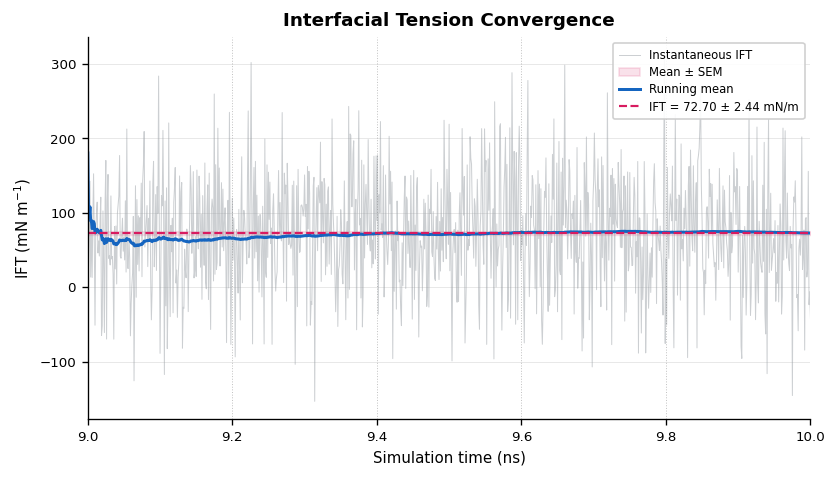

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

BEGIN_PS = 9000.0

XVG = Path("analysis/pressure_tensor.xvg")
GRO = Path("interface/emSys.gro")


def read_xvg(path):
    rows = []

    with open(path) as handle:
        for line in handle:
            line = line.strip()

            if line and not line.startswith(("#", "@", "&", ";")):
                rows.append([float(value) for value in line.split()])

    return np.asarray(rows)


# Read pressure data: time, Pxx, Pyy, Pzz
data = read_xvg(XVG)
time, pxx, pyy, pzz = data.T

# Read box Z dimension from the GRO file
gro_lines = GRO.read_text().splitlines()
box_z = float(gro_lines[-1].split()[2])

print(f"Loaded {len(data)} rows")
print(f"Box Z = {box_z:.4f} nm")

# Calculate instantaneous interfacial tension
ift = 0.05 * box_z * (pzz - 0.5 * (pxx + pyy))

# Keep data after BEGIN_PS
keep = time >= BEGIN_PS
time_used = time[keep]
ift_used = ift[keep]

if len(ift_used) < 5:
    raise ValueError(
        "Choose an earlier BEGIN_PS; fewer than five data points remain."
    )

# Five-block analysis
n_blocks = 5
block_size = len(ift_used) // n_blocks
trimmed = ift_used[:n_blocks * block_size]

block_means = trimmed.reshape(n_blocks, block_size).mean(axis=1)

mean_ift = block_means.mean()
sem_ift = block_means.std(ddof=1) / np.sqrt(n_blocks)

print(
    f"IFT = {mean_ift:.2f} ± {sem_ift:.2f} mN/m "
    f"(block SEM, n={n_blocks})"
)

# Calculate running mean
running_mean = np.cumsum(ift_used) / np.arange(1, len(ift_used) + 1)

# Convert time from ps to ns
time_ns = time_used / 1000.0

# Create compact figure
fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

# Instantaneous IFT
ax.plot(
    time_ns,
    ift_used,
    color="#9aa0a6",
    linewidth=0.6,
    alpha=0.5,
    label="Instantaneous IFT",
)

# Mean ± SEM region
ax.fill_between(
    time_ns,
    mean_ift - sem_ift,
    mean_ift + sem_ift,
    color="#d81b60",
    alpha=0.13,
    label="Mean ± SEM",
)

# Running mean
ax.plot(
    time_ns,
    running_mean,
    color="#1565c0",
    linewidth=1.8,
    label="Running mean",
)

# Final block-average IFT
ax.axhline(
    mean_ift,
    color="#d81b60",
    linewidth=1.3,
    linestyle="--",
    label=f"IFT = {mean_ift:.2f} ± {sem_ift:.2f} mN/m",
)

# Block boundaries
for block in range(1, n_blocks):
    index = block * block_size

    if index < len(time_ns):
        ax.axvline(
            time_ns[index],
            color="#555555",
            linewidth=0.6,
            linestyle=":",
            alpha=0.35,
        )

# Title and axis labels
ax.set_title(
    "Interfacial Tension Convergence",
    fontsize=11,
    fontweight="bold",
    pad=7,
)

ax.set_xlabel("Simulation time (ns)", fontsize=9)
ax.set_ylabel(r"IFT (mN m$^{-1}$)", fontsize=9)

# Tick-label size
ax.tick_params(
    axis="both",
    labelsize=8,
)

# Horizontal grid
ax.grid(
    axis="y",
    color="#d9d9d9",
    linewidth=0.6,
    alpha=0.6,
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(time_ns[0], time_ns[-1])

# Compact legend
ax.legend(
    fontsize=7,
    frameon=True,
    framealpha=0.9,
    loc="best",
    borderpad=0.5,
    labelspacing=0.35,
    handlelength=1.8,
)

fig.tight_layout(pad=0.8)
plt.show()

> <span style="color:#27AE60"><b>✅ Validation:</b></span> The running mean should approach a plateau. Repeat the calculation with a slightly later `BEGIN_PS`; the result should not change strongly.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> Large instantaneous fluctuations are normal. A steadily drifting running mean usually means that more equilibration or a longer production trajectory is needed.

### 10.4 Alternative: calculate and plot IFT directly from `ift.xvg`

Use this cell when `analysis/ift.xvg` has already been prepared by selecting `#Surf*SurfTen` with `gmx energy`. GROMACS stores this term in bar nm. For a periodic slab containing two interfaces, convert it to the IFT of one interface using

$$
\gamma\;(\mathrm{mN\,m^{-1}})=0.05\times\texttt{\#Surf*SurfTen}.
$$

The conversion is applied before calculating the block average, SEM, and running mean.

IFT from ift.xvg = 70.84 ± 1.74 mN/m (block SEM, n=10)


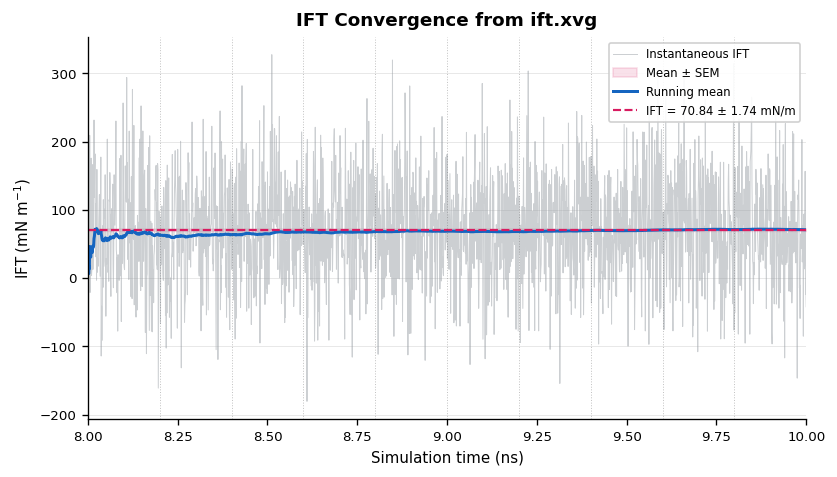

In [11]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

BEGIN_PS = 8000.0
IFT_XVG = Path("analysis/ift.xvg")


def read_xvg(path):
    rows = []
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if line and not line.startswith(("#", "@", "&", ";")):
                rows.append([float(value) for value in line.split()])
    return np.asarray(rows)


# Read time (ps) and #Surf*SurfTen (bar nm)
data = read_xvg(IFT_XVG)
time = data[:, 0]
surface_term = data[:, 1]

# 1 bar nm = 0.1 mN/m; divide by two periodic interfaces
ift = 0.05 * surface_term  # mN/m

keep = time >= BEGIN_PS
time_used = time[keep]
ift_used = ift[keep]

if len(ift_used) < 5:
    raise ValueError("Choose an earlier BEGIN_PS; fewer than five data points remain.")

# Same five-block averaging used in Section 10.3
n_blocks = 10
block_size = len(ift_used) // n_blocks
trimmed = ift_used[:n_blocks * block_size]
block_means = trimmed.reshape(n_blocks, block_size).mean(axis=1)
mean_ift = block_means.mean()
sem_ift = block_means.std(ddof=1) / np.sqrt(n_blocks)
running_mean = np.cumsum(ift_used) / np.arange(1, len(ift_used) + 1)
time_ns = time_used / 1000.0

print(
    f"IFT from ift.xvg = {mean_ift:.2f} ± {sem_ift:.2f} mN/m "
    f"(block SEM, n={n_blocks})"
)

fig, ax = plt.subplots(figsize=(7, 4), dpi=120)
ax.plot(time_ns, ift_used, color="#9aa0a6", linewidth=0.6, alpha=0.5,
        label="Instantaneous IFT")
ax.fill_between(time_ns, mean_ift - sem_ift, mean_ift + sem_ift,
                color="#d81b60", alpha=0.13, label="Mean ± SEM")
ax.plot(time_ns, running_mean, color="#1565c0", linewidth=1.8,
        label="Running mean")
ax.axhline(mean_ift, color="#d81b60", linewidth=1.3, linestyle="--",
           label=f"IFT = {mean_ift:.2f} ± {sem_ift:.2f} mN/m")

for block in range(1, n_blocks):
    index = block * block_size
    if index < len(time_ns):
        ax.axvline(time_ns[index], color="#555555", linewidth=0.6,
                   linestyle=":", alpha=0.35)

ax.set_title("IFT Convergence from ift.xvg", fontsize=11, fontweight="bold", pad=7)
ax.set_xlabel("Simulation time (ns)", fontsize=9)
ax.set_ylabel(r"IFT (mN m$^{-1}$)", fontsize=9)
ax.tick_params(axis="both", labelsize=8)
ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.6)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(time_ns[0], time_ns[-1])
ax.legend(fontsize=7, frameon=True, framealpha=0.9, loc="best")
fig.tight_layout(pad=0.8)
plt.show()

> <span style="color:#27AE60"><b>✅ Validation:</b></span> For matching time frames, Sections 10.3 and 10.4 should give the same IFT within numerical precision.

### 10.5 Center the trajectory for a density check

Create groups for H₂ and brine, then center the brine slab. At the `make_ndx` prompt, enter:

```text
r H2
r SOL | r NA | r CL
name 2 Brine
q
```

The group numbers shown by GROMACS may differ. Use the displayed group names in the next command.

```bash
cd H2_brine_IFT/analysis

gmx make_ndx -f ../production/nvt.tpr -o index.ndx
gmx trjconv -s ../production/nvt.tpr -f ../production/nvt.xtc \
    -n index.ndx -o nvt_centered.xtc -center -pbc mol -ur rect -boxcenter rect
```

For `trjconv`, select **Brine** for centering and **System** for output.

> <span style="color:#27AE60"><b>✅ Validation:</b></span> Visualize a few frames and confirm that the brine slab remains near the box centre.

### 10.6 Calculate simple density profiles

Run `gmx density` twice: first select **H2**, then select **Brine**.

```bash
cd H2_brine_IFT/analysis

gmx density -f nvt_centered.xtc -s ../production/nvt.tpr -n index.ndx \
    -o density_h2.xvg -d Z -sl 100 -dens mass

gmx density -f nvt_centered.xtc -s ../production/nvt.tpr -n index.ndx \
    -o density_brine.xvg -d Z -sl 100 -dens mass
```

### 10.7 Plot the density profiles

The density plot is a structural check rather than a second IFT calculation. It should show a central brine-rich region, H₂-rich regions on both sides, and two transition zones.

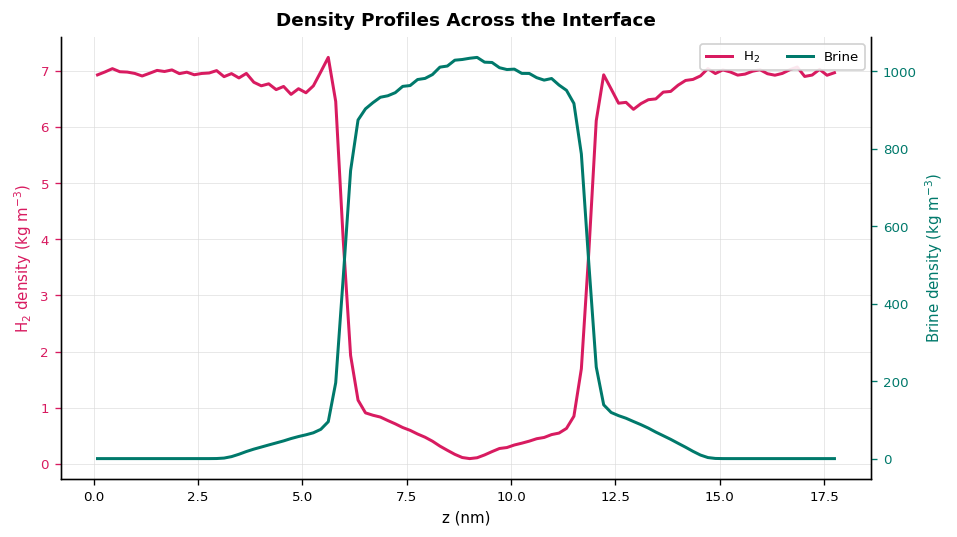

In [21]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

H2_DENSITY_XVG = Path("analysis/density_h2.xvg")
BRINE_DENSITY_XVG = Path("analysis/density_brine.xvg")


def read_xvg(path):
    rows = []
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if line and not line.startswith(("#", "@", "&", ";")):
                rows.append([float(value) for value in line.split()])
    return np.asarray(rows)


# Check that both files are in the expected location
for path in (H2_DENSITY_XVG, BRINE_DENSITY_XVG):
    if not path.is_file():
        raise FileNotFoundError(
            f"Could not find '{path}'. "
            f"Current working directory: '{Path.cwd()}'"
        )

h2 = read_xvg(H2_DENSITY_XVG)
brine = read_xvg(BRINE_DENSITY_XVG)

fig, ax1 = plt.subplots(figsize=(8, 4.5), dpi=120)
ax2 = ax1.twinx()

line_h2, = ax1.plot(
    h2[:, 0],
    h2[:, 1],
    color="#d81b60",
    linewidth=1.8,
    label=r"H$_2$",
)

line_brine, = ax2.plot(
    brine[:, 0],
    brine[:, 1],
    color="#00796b",
    linewidth=1.8,
    label="Brine",
)

ax1.set_title(
    "Density Profiles Across the Interface",
    fontsize=11,
    fontweight="bold",
    pad=7,
)
ax1.set_xlabel("z (nm)", fontsize=9)
ax1.set_ylabel(
    r"H$_2$ density (kg m$^{-3}$)",
    color="#d81b60",
    fontsize=9,
)
ax2.set_ylabel(
    r"Brine density (kg m$^{-3}$)",
    color="#00796b",
    fontsize=9,
)

ax1.tick_params(axis="x", labelsize=8)
ax1.tick_params(axis="y", labelsize=8, colors="#d81b60")
ax2.tick_params(axis="y", labelsize=8, colors="#00796b")

ax1.grid(axis="both", color="#d9d9d9", linewidth=0.6, alpha=0.6)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

ax1.legend(
    handles=[line_h2, line_brine],
    fontsize=8,
    loc="upper right",
    ncol=2,
    frameon=True,
    framealpha=0.9,
)

fig.tight_layout(pad=0.8)
plt.show()

### 10.8 Gibbs dividing surface and surface excess

For one interface, choose water as the reference component and define the Gibbs dividing surface $z_G$ so that its surface excess is zero:

$$
0=\int_{z_a}^{z_G}[\rho_{\mathrm{w}}(z)-\rho_{\mathrm{w}}^{\alpha}]\,dz
+\int_{z_G}^{z_b}[\rho_{\mathrm{w}}(z)-\rho_{\mathrm{w}}^{\beta}]\,dz.
$$

For another species $i$, the surface excess relative to that water dividing surface is

$$
\Gamma_i=\int_{z_a}^{z_G}[\rho_i(z)-\rho_i^{\alpha}]\,dz
+\int_{z_G}^{z_b}[\rho_i(z)-\rho_i^{\beta}]\,dz.
$$

Here, $\alpha$ and $\beta$ denote the bulk phases on the left and right sides of the selected interface. Because the periodic slab contains two interfaces, analyze the left and right interfaces separately and only then average their $\Gamma_i$ values. With number density in nm⁻³ and $z$ in nm, $\Gamma_i$ is reported in nm⁻².

Use one representative site per molecule: `OW` for water and `MH2` for H₂. Na⁺ and Cl⁻ already contain one atom per ion. This prevents the molecular number densities from being multiplied by the number of sites in each model.

<details>

<summary><strong>📘 Optional: Understanding the Gibbs dividing surface and surface excess</strong></summary>

<br>

### Gibbs dividing surface

At the molecular scale, an interface is not a sharp boundary. Instead, the density changes continuously across a finite region between bulk phases $\alpha$ and $\beta$. Consequently, there is no unique molecular position at which one phase ends and the other begins.

The **Gibbs dividing surface (GDS)** replaces this diffuse interface with an imaginary, zero-thickness plane located at

$$
z=z_{\mathrm G}.
$$

The GDS is not a physical membrane. It is a mathematical reference used to define the volumes of the two bulk phases and calculate interfacial excess quantities consistently.

<p align="center">

<img src="./Figures/The-Gibbs-dividing-surface-separates-the-interface-region-to-obtain-the-sharp_W640.jpg"
    alt="Molecular density profiles, 10–90 interfaces, and water Gibbs dividing surfaces"
    width="450">

</p>

The position of the GDS is not unique until a convention is selected. In an aqueous system, water is commonly used as the reference component, and the GDS is positioned so that the water surface excess is zero:

$$
\Gamma_{\mathrm w}=0.
$$

For one interface, the water GDS is therefore defined by

$$
0=
\int_{z_a}^{z_{\mathrm G}}
\left[\rho_{\mathrm w}(z)-\rho_{\mathrm w}^{\alpha}\right]\,dz
+
\int_{z_{\mathrm G}}^{z_b}
\left[\rho_{\mathrm w}(z)-\rho_{\mathrm w}^{\beta}\right]\,dz.
$$

Here:

* $z_a$ lies in bulk phase $\alpha$;
* $z_b$ lies in bulk phase $\beta$;
* $\rho_{\mathrm w}^{\alpha}$ and $\rho_{\mathrm w}^{\beta}$ are the bulk water densities.

This is an **equimolar** or **equal-area** condition. It means that the ideal sharp water profile divided at $z_{\mathrm G}$ contains the same integrated amount of water as the real continuous profile.

The condition $\Gamma_{\mathrm w}=0$ does not mean that water is absent from the interface. It only defines the position of the reference surface.

---

### Surface excess

After determining the water GDS, the surface excess of another species $i$ is calculated relative to the same dividing surface:

$$
\Gamma_i=
\int_{z_a}^{z_{\mathrm G}}
\left[\rho_i(z)-\rho_i^{\alpha}\right]\,dz
+
\int_{z_{\mathrm G}}^{z_b}
\left[\rho_i(z)-\rho_i^{\beta}\right]\,dz.
$$

Surface excess measures the difference between the actual amount of species $i$ and the amount expected if the two ideal bulk phases extended uniformly up to the GDS.

Its sign is interpreted as

$$
\Gamma_i>0
\quad\Longrightarrow\quad
\text{net interfacial enrichment or adsorption},
$$

$$
\Gamma_i<0
\quad\Longrightarrow\quad
\text{net interfacial depletion or exclusion},
$$

and

$$
\Gamma_i=0
\quad\Longrightarrow\quad
\text{no net excess relative to the water GDS}.
$$

Surface excess is an integrated property. A local density peak indicates local enrichment, but it does not necessarily imply $\Gamma_i>0$, because enrichment in one region may be offset by depletion elsewhere.

If density is expressed in $\mathrm{nm}^{-3}$ and $z$ in $\mathrm{nm}$, then

$$
[\Gamma_i]=\mathrm{nm}^{-2}.
$$

---

### The 10–90 interfacial thickness

The **10–90 method** is separate from the Gibbs construction. It measures the width of the diffuse interface rather than defining its thermodynamic reference position.

For water, define a density normalized between its two bulk values:

$$
f_{\mathrm w}(z)
=
\frac{
\rho_{\mathrm w}(z)-\rho_{\mathrm w}^{\beta}
}{
\rho_{\mathrm w}^{\alpha}-\rho_{\mathrm w}^{\beta}
}.
$$

The positions $z_{10}$ and $z_{90}$ satisfy

$$
f_{\mathrm w}(z_{10})=0.10
$$

and

$$
f_{\mathrm w}(z_{90})=0.90.
$$

The **10–90 interfacial thickness**, also called the **10–90 interfacial width** or **90/10 interface region**, is

$$
L_{90-10}^{(\mathrm w)}
=
\left|z_{90}-z_{10}\right|.
$$

Its interpretation is

$$
\text{small }L_{90-10}^{(\mathrm w)}
\Rightarrow
\text{sharper interface},
$$

$$
\text{large }L_{90-10}^{(\mathrm w)}
\Rightarrow
\text{broader interface}.
$$

The two constructions therefore provide different information:

| Quantity                  | Purpose                                         | Units     |
| ------------------------- | ----------------------------------------------- | --------- |
| $z_{\mathrm G}$           | Defines the reference position of the interface | nm        |
| $L_{90-10}^{(\mathrm w)}$ | Measures the width of the density transition    | nm        |
| $\Gamma_i$                | Measures net adsorption or depletion            | nm$^{-2}$ |

The GDS is calculated from the zero-excess condition and is not necessarily the midpoint of the 10–90 region, the 50% density position, or the crossing point of two density profiles.


</details>


Create an index for the four species:

```bash
cd H2_brine_IFT/analysis
gmx make_ndx -f ../production/nvt.tpr -o gds_index.ndx
```

At the prompt, create and clearly name the following groups. Replace `<n>` with the group number printed by GROMACS after each selection.

```text
a OW
name <n> Water_O
r H2 & a MH2
name <n> H2_center
r NA
name <n> Sodium
r CL
name <n> Chloride
q
```

Then calculate number-density profiles on the same grid, selecting the named group in each command:

```bash
gmx density -f ../production/nvt.xtc -s ../production/nvt.tpr -n gds_index.ndx \
    -o density_water_ow.xvg -d Z -sl 100 -dens number

gmx density -f ../production/nvt.xtc -s ../production/nvt.tpr -n gds_index.ndx \
    -o density_h2_center.xvg -d Z -sl 100 -dens number

gmx density -f ../production/nvt.xtc -s ../production/nvt.tpr -n gds_index.ndx \
    -o density_na.xvg -d Z -sl 100 -dens number

gmx density -f ../production/nvt.xtc -s ../production/nvt.tpr -n gds_index.ndx \
    -o density_cl.xvg -d Z -sl 100 -dens number
```

Water Gibbs dividing surfaces:
  Left: z_G = 5.969 nm
  Right: z_G = 11.843 nm

Surface excess relative to the water GDS (nm^-2):
Species            Left        Right      Average
Water            0.0000       0.0000       0.0000
H2               0.1821       0.1821       0.1821
Na+             -0.2489      -0.2073      -0.2281
Cl-             -0.2568      -0.2120      -0.2344


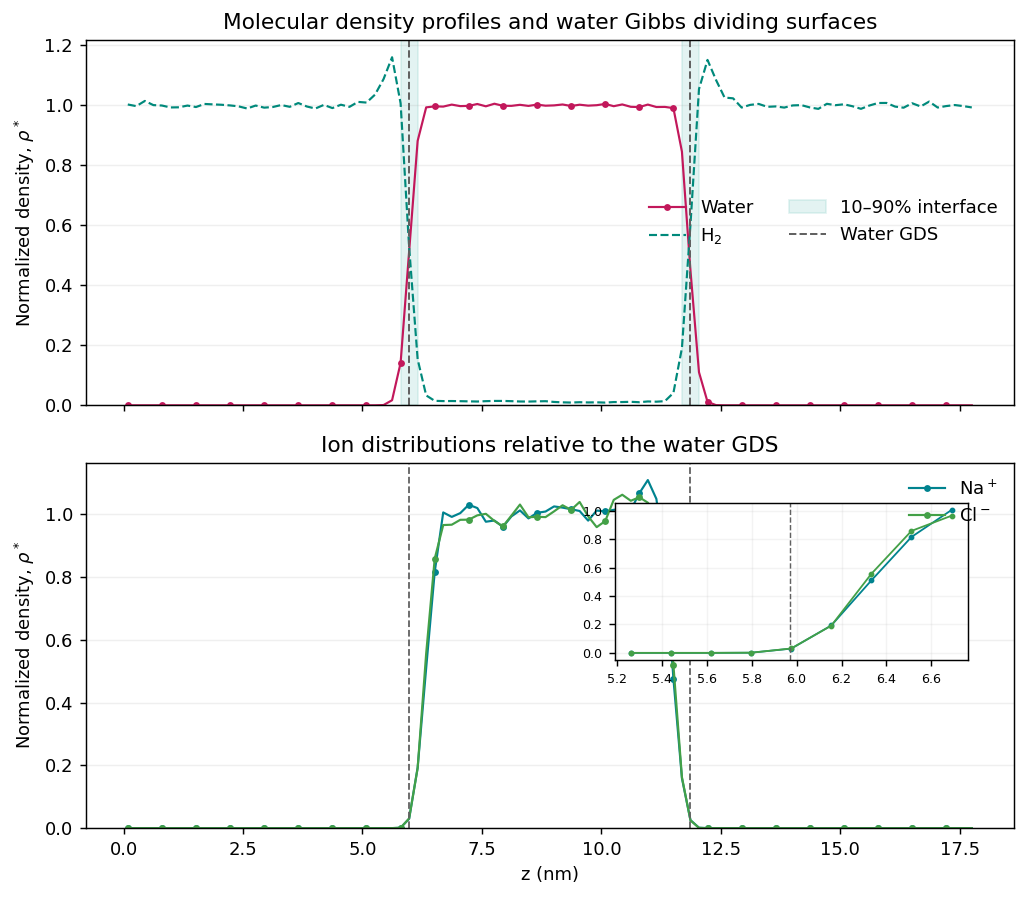

In [22]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

PROFILE_DIR = Path("analysis")
PROFILE_FILES = {
    "Water": PROFILE_DIR / "density_water_ow.xvg",
    "H2": PROFILE_DIR / "density_h2_center.xvg",
    "Na+": PROFILE_DIR / "density_na.xvg",
    "Cl-": PROFILE_DIR / "density_cl.xvg",
}

# Fractions of the box used as bulk plateau regions. Adjust only after
# inspecting the profiles and confirming that the masks avoid both interfaces.
GAS_EDGE_FRACTION = 0.12
LIQUID_HALF_FRACTION = 0.08


def read_two_column_xvg(path):
    rows = []
    with open(path) as handle:
        for line in handle:
            line = line.strip()
            if line and not line.startswith(("#", "@", "&", ";")):
                rows.append([float(value) for value in line.split()[:2]])
    data = np.asarray(rows, dtype=float)
    if data.ndim != 2 or data.shape[1] != 2:
        raise ValueError(f"No two-column density data found in {path}")
    return data


profiles = {name: read_two_column_xvg(path) for name, path in PROFILE_FILES.items()}
z = profiles["Water"][:, 0]
rho = {name: data[:, 1] for name, data in profiles.items()}

for name, data in profiles.items():
    if len(data) != len(z) or not np.allclose(data[:, 0], z):
        raise ValueError(f"{name} does not use the same z grid as Water.")

z_min, z_max = z[0], z[-1]
box_span = z_max - z_min
z_mid = 0.5 * (z_min + z_max)
gas_width = GAS_EDGE_FRACTION * box_span
liquid_half_width = LIQUID_HALF_FRACTION * box_span

gas_mask = (z <= z_min + gas_width) | (z >= z_max - gas_width)
liquid_mask = np.abs(z - z_mid) <= liquid_half_width

if gas_mask.sum() < 3 or liquid_mask.sum() < 3:
    raise ValueError("Bulk masks contain too few bins; adjust the plateau fractions.")

bulk = {
    name: {
        "gas": values[gas_mask].mean(),
        "liquid": values[liquid_mask].mean(),
    }
    for name, values in rho.items()
}

left_limits = (z_min + gas_width, z_mid - liquid_half_width)
right_limits = (z_mid + liquid_half_width, z_max - gas_width)
trapz = getattr(np, "trapezoid", np.trapz)


def window_data(values, limits):
    z_a, z_b = limits
    mask = (z >= z_a) & (z <= z_b)
    if mask.sum() < 3:
        raise ValueError(f"Too few bins in interface window {limits}.")
    return z[mask], values[mask]


def gibbs_position(reference_density, limits, rho_alpha, rho_beta):
    z_window, rho_window = window_data(reference_density, limits)
    z_a, z_b = z_window[0], z_window[-1]
    denominator = rho_alpha - rho_beta
    if np.isclose(denominator, 0.0):
        raise ValueError("Reference bulk densities are indistinguishable.")
    integral = trapz(rho_window, z_window)
    z_g = (integral + rho_alpha * z_a - rho_beta * z_b) / denominator
    if not z_a <= z_g <= z_b:
        raise ValueError(
            f"Calculated GDS {z_g:.3f} nm lies outside [{z_a:.3f}, {z_b:.3f}] nm. "
            "Inspect the bulk masks and centered density profiles."
        )
    return z_g


def surface_excess(values, limits, z_g, rho_alpha, rho_beta):
    z_window, rho_window = window_data(values, limits)
    z_a, z_b = z_window[0], z_window[-1]
    return (
        trapz(rho_window, z_window)
        - rho_alpha * (z_g - z_a)
        - rho_beta * (z_b - z_g)
    )


interfaces = [
    {"name": "Left", "limits": left_limits, "alpha": "gas", "beta": "liquid"},
    {"name": "Right", "limits": right_limits, "alpha": "liquid", "beta": "gas"},
]

for interface in interfaces:
    interface["z_g"] = gibbs_position(
        rho["Water"],
        interface["limits"],
        bulk["Water"][interface["alpha"]],
        bulk["Water"][interface["beta"]],
    )

surface_excesses = {}
for name, values in rho.items():
    gamma_values = []
    for interface in interfaces:
        gamma_values.append(
            surface_excess(
                values,
                interface["limits"],
                interface["z_g"],
                bulk[name][interface["alpha"]],
                bulk[name][interface["beta"]],
            )
        )
    surface_excesses[name] = gamma_values

print("Water Gibbs dividing surfaces:")
for interface in interfaces:
    print(f"  {interface['name']}: z_G = {interface['z_g']:.3f} nm")

print("\nSurface excess relative to the water GDS (nm^-2):")
print(f"{'Species':<10} {'Left':>12} {'Right':>12} {'Average':>12}")
for name, values in surface_excesses.items():
    average = np.mean(values)
    print(f"{name:<10} {values[0]:12.4f} {values[1]:12.4f} {average:12.4f}")

# Bulk-normalized densities, rho*, for a figure comparable across species.
water_star = rho["Water"] / bulk["Water"]["liquid"]
h2_star = rho["H2"] / bulk["H2"]["gas"]
na_star = rho["Na+"] / bulk["Na+"]["liquid"]
cl_star = rho["Cl-"] / bulk["Cl-"]["liquid"]

fig, (ax_top, ax_ion) = plt.subplots(2, 1, figsize=(8, 7), sharex=True, dpi=130)

ax_top.plot(z, water_star, "o-", ms=2.8, markevery=4, lw=1.2,
            color="#c2185b", label="Water")
ax_top.plot(z, h2_star, "--", lw=1.2, color="#00897b", label="H$_2$")

for number, interface in enumerate(interfaces):
    z_window, water_window = window_data(water_star, interface["limits"])
    transition = (water_window >= 0.1) & (water_window <= 0.9)
    if transition.any():
        ax_top.axvspan(
            z_window[transition].min(), z_window[transition].max(),
            color="#80cbc4", alpha=0.22,
            label="10–90% interface" if number == 0 else None,
        )
    ax_top.axvline(
        interface["z_g"], color="#616161", ls="--", lw=1.1,
        label="Water GDS" if number == 0 else None,
    )

ax_top.set_ylabel(r"Normalized density, $\rho^*$")
ax_top.set_title("Molecular density profiles and water Gibbs dividing surfaces")
ax_top.set_ylim(bottom=0)
ax_top.legend(frameon=False, ncol=2)
ax_top.grid(axis="y", alpha=0.2)

ax_ion.plot(z, na_star, "o-", ms=2.8, markevery=4, lw=1.2,
            color="#00838f", label="Na$^+$")
ax_ion.plot(z, cl_star, "o-", ms=2.8, markevery=4, lw=1.2,
            color="#43a047", label="Cl$^-$")
for interface in interfaces:
    ax_ion.axvline(interface["z_g"], color="#616161", ls="--", lw=1.0)
ax_ion.set_xlabel("z (nm)")
ax_ion.set_ylabel(r"Normalized density, $\rho^*$")
ax_ion.set_title("Ion distributions relative to the water GDS")
ax_ion.set_ylim(bottom=0)
ax_ion.legend(frameon=False)
ax_ion.grid(axis="y", alpha=0.2)

# Inset around the left interface to reveal preferential ion adsorption.
left_gds = interfaces[0]["z_g"]
zoom = (z >= left_gds - 0.8) & (z <= left_gds + 0.8)
inset = ax_ion.inset_axes([0.57, 0.46, 0.38, 0.43])
inset.plot(z[zoom], na_star[zoom], "o-", ms=2.2, lw=1.0, color="#00838f")
inset.plot(z[zoom], cl_star[zoom], "o-", ms=2.2, lw=1.0, color="#43a047")
inset.axvline(left_gds, color="#616161", ls="--", lw=0.8)
inset.tick_params(labelsize=7)
inset.grid(alpha=0.15)

fig.tight_layout()
plt.show()

> <span style="color:#27AE60"><b>✅ Validation:</b></span> The calculated water surface excess should be approximately zero at both dividing surfaces. The left and right $z_G$ values should lie inside their respective transition regions, and the two independently calculated $\Gamma_i$ values should be reasonably consistent.
>
> <span style="color:#EB5757"><b>⚠️ Troubleshooting:</b></span> If a GDS falls outside its interface window, first verify that the brine slab is centered and that the selected gas and liquid plateau regions are flat. Adjust `GAS_EDGE_FRACTION` and `LIQUID_HALF_FRACTION` only after inspecting the plotted profiles. Strong disagreement between the two interfaces can indicate inadequate sampling, imperfect centering, or a genuinely asymmetric slab.

A positive $\Gamma_i$ indicates interfacial enrichment relative to the extrapolated bulk phases, whereas a negative value indicates depletion. The normalized profiles $\rho^*$ are used only to compare profile shapes in the figure; calculate $\Gamma_i$ from the original number densities, as done above. Ion peaks close to $z_G$ indicate local layering, but the integrated $\Gamma_i$ determines whether the complete interface is enriched or depleted.

# References for GROMACS definitions

- GROMACS current reference manual: <https://manual.gromacs.org/current/reference-manual/>
- GROMACS `gmx energy`: <https://manual.gromacs.org/current/onlinehelp/gmx-energy.html>
- GROMACS `gmx trjconv`: <https://manual.gromacs.org/current/onlinehelp/gmx-trjconv.html>
- GROMACS `gmx density`: <https://manual.gromacs.org/current/onlinehelp/gmx-density.html>